# eDNA Metabarcoding Pipeline Analysis: Lake Geneva
### A Reproducible Workflow for MinION Amplicon Sequencing (18S & COI)
**Project:** Genorobotics Semester Project (EPFL)

**Databases:** PR2 (18S rRNA) & Porter CO1 Classifier (COI)

**Marker:** 18S rRNA (Eukaryotic Biodiversity) & COI (Metazoan Target)

## 0. Critical Review: Limitations & Technical Constraints

This notebook uses the **PR2 database** for 18S and the **Porter CO1 Classifier** for COI — the recommended combination based on our multi-database comparison.

### 1. PR2 for 18S: Improved Protist Classification
PR2 is an expert-curated protist/plankton database that **outperforms SILVA at every taxonomic rank** for our lake water samples:
* **Better ciliate taxonomy:** PR2 resolves ciliates that SILVA labels as "Unassigned" or misclassifies.
* **No exotic artifacts:** The "Brazilian Bee" effect seen with SILVA is reduced because PR2 has better freshwater protist coverage.
* **9-level taxonomy:** Clean hierarchy designed for eukaryotic diversity.

### 2. Porter CO1 for COI: Balanced Coverage
The Porter CO1 Classifier (6.8 GB) provides a middle ground between MIDORI2 and eKOI:
* **10.3% phylum-level** classification at conf ≥ 0.8 (Water dataset, n=6,281 OTUs).
* **5.0% species-level** — better than eKOI (0.7%) but less consistent than MIDORI2 (8.9%).
* Pre-formatted for SINTAX/VSEARCH — direct drop-in replacement.

### 3. Ciliate Dominance
Both markers are dominated by ciliate DNA. This is a biological reality of lake eDNA, not a pipeline or database issue. Ciliate-blocking primers would be needed to improve vertebrate detection.

### 4. Clustering and Size Selection
* **95% Identity Clustering:** Adapted for Nanopore's ~5% error rate. Nanopore has no PCR duplicates, so dereplication is not applicable.
* **18S Filter:** Reads > 3000 bp discarded (concatemers). **COI Filter:** 300–1000 bp range.

## Key Results
* **PR2 advantage:** Significantly better protist/plankton classification than SILVA for 18S.
* **Porter advantage:** Balanced COI classification with good coverage-to-speed ratio.
* **Confirmed species (BLAST):** *Daphnia galeata*, *Cyclops abyssorum*, *Dreissena rostriformis* (invasive quagga mussel).

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from pathlib import Path
from Bio import SeqIO
from matplotlib import cm

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'figure.dpi': 150,        
    'savefig.dpi': 300,       
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Define a function to clean sample names (e.g., "Sample_barcode01" -> "01")
def clean_sample_names(columns):
    return [c.replace('Sample_barcode', '').replace('Sample_', '') for c in columns]

# Auto-detect taxonomy column prefix (PR2_ or MIDORI_)
def get_tax_prefix(df):
    for col in df.columns:
        if col.startswith("PR2_"):
            return "PR2"
        if col.startswith("Porter_"):
            return "Porter"
        if col.startswith("MIDORI_"):
            return "MIDORI"
    return "PR2"

BASE = Path("out/Water_eDNA_18S_COI_14_01_26")

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

def stacked_bar_compare(df, rank, prefix, marker_label, sample_cols, top_n=10, conf_threshold=None):
    """Two side-by-side stacked bars: left includes Unassigned, right excludes it.

    - Blanks low-confidence assignments (< conf_threshold) before grouping.
    - Keeps Unassigned in the data so it\'s visible in the left panel with
      a dedicated gray color + legend entry.
    - Right panel drops Unassigned and renormalizes to 100% of assigned reads,
      useful when Unassigned dominates (e.g. soil COI).
    """
    if conf_threshold is None:
        conf_threshold = CONF_THRESHOLD
    col = f'{prefix}_{rank}'
    conf_col = f'{prefix}_{rank}_Conf'
    d = df.copy()
    if conf_col in d.columns:
        d.loc[pd.to_numeric(d[conf_col], errors='coerce').fillna(0) < conf_threshold, col] = ''
    d[col] = d[col].replace('', 'Unassigned').fillna('Unassigned')
    grouped = d.groupby(col)[sample_cols].sum()

    unassigned_row = grouped.loc['Unassigned'] if 'Unassigned' in grouped.index else None
    assigned = grouped.drop('Unassigned', errors='ignore').copy()
    assigned['Total'] = assigned.sum(axis=1)
    assigned = assigned.sort_values('Total', ascending=False)
    top_idx = assigned.head(top_n).index
    top_data = assigned.loc[top_idx].drop(columns='Total')
    others_data = assigned.loc[~assigned.index.isin(top_idx)].drop(columns='Total').sum()

    # Build LEFT (with Unassigned) and RIGHT (without)
    left = top_data.copy()
    left.loc['Others'] = others_data
    if unassigned_row is not None:
        left.loc['Unassigned'] = unassigned_row
    left_pct = left.div(left.sum(axis=0).replace(0, np.nan), axis=1) * 100
    left_pct = left_pct.fillna(0)

    right = top_data.copy()
    right.loc['Others'] = others_data
    right_pct = right.div(right.sum(axis=0).replace(0, np.nan), axis=1) * 100
    right_pct = right_pct.fillna(0)

    def colors_for(data_):
        palette = cm.tab20(np.linspace(0, 1, max(len(data_) - 2, 1)))
        out = []
        pi = 0
        for name in data_.index:
            if name == 'Unassigned':
                out.append('#D3D3D3')
            elif name == 'Others':
                out.append('#696969')
            else:
                out.append(palette[pi % len(palette)])
                pi += 1
        return out

    # Report Unassigned share for context
    if unassigned_row is not None:
        total_reads = grouped.sum().sum()
        un_share = 100 * unassigned_row.sum() / total_reads if total_reads else 0
        print(f'[{marker_label}] {rank}: Unassigned = {un_share:.1f}% of reads')

    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
    for ax, data, subtitle in [(axes[0], left_pct, 'including Unassigned'),
                                (axes[1], right_pct, 'excluding Unassigned (renormalized)')]:
        data = data.copy()
        data.columns = clean_sample_names(data.columns)
        data.T.plot(kind='bar', stacked=True, ax=ax, width=0.85, color=colors_for(data))
        ax.set_title(f'{rank}-Level Composition ({marker_label}, {prefix})\n{subtitle}',
                     fontweight='bold', fontsize=11)
        ax.set_ylabel('Relative Abundance (%)')
        ax.set_xlabel('Sample')
        h, l = ax.get_legend_handles_labels()
        ax.legend(reversed(h), reversed(l), bbox_to_anchor=(1.02, 1), loc='upper left',
                  title=rank, fontsize=8)
        for _i, _s in enumerate(data.columns):
            if data[_s].sum() == 0:
                ax.text(_i, 2, 'ND', ha='center', va='bottom', fontsize=9,
                        color='gray', fontstyle='italic')
        ax.set_ylim(0, 105)
    plt.tight_layout()
    add_conf_note(fig, 'filtered')
    plt.show()

# Confidence-interpretation caption helper
_CONF_NOTES = {
    'filtered':   'SINTAX confidence \u2265 0.8 applied \u2014 lower-confidence calls treated as Unassigned.',
    'unfiltered': 'No confidence filter applied \u2014 includes low-confidence assignments. Interpret taxa cautiously.',
    'blast':      'Based on BLAST vs NCBI identity (not SINTAX confidence).',
    'qc':         'Pre-taxonomy QC plot \u2014 confidence filter not applicable.',
    'meta':       'Pipeline metadata \u2014 confidence filter not applicable.',
}
def add_conf_note(fig=None, kind='filtered'):
    if fig is None:
        fig = plt.gcf()
    txt = _CONF_NOTES.get(kind, _CONF_NOTES['filtered'])
    fig.text(0.5, -0.02, txt, ha='center', va='top', fontsize=9,
             style='italic', color='#555555', wrap=True)


## Table Headers & Data Structure
Inspect the comprehensive taxonomy CSV files to verify column names and data shape.

In [24]:
# Load both datasets
df_18s = pd.read_csv(BASE / 'taxonomy_summary/18S/pr2/comprehensive_taxonomy_18S.csv')
df_coi_raw = pd.read_csv(BASE / 'taxonomy_summary/COI/porter/comprehensive_taxonomy_COI.csv')

prefix_18s = get_tax_prefix(df_18s)
prefix_coi = get_tax_prefix(df_coi_raw)

for label, df, pfx in [("18S", df_18s, prefix_18s), ("COI", df_coi_raw, prefix_coi)]:
    print(f"\n{'='*60}")
    print(f"  {label} ({pfx} database)  —  {df.shape[0]} OTUs × {df.shape[1]} columns")
    print(f"{'='*60}")
    
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{pfx}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  18S (PR2 database)  —  38828 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['PR2_Domain', 'PR2_Domain_Conf', 'PR2_Phylum', 'PR2_Phylum_Conf', 'PR2_Class', 'PR2_Class_Conf', 'PR2_Order', 'PR2_Order_Conf', 'PR2_Family', 'PR2_Family_Conf', 'PR2_Genus', 'PR2_Genus_Conf', 'PR2_Species', 'PR2_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,PR2_Order_Conf,PR2_Family,PR2_Family_Conf,PR2_Genus,PR2_Genus_Conf,PR2_Species,PR2_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_003921,0.985322,1,0.004608,0.099583,0.097004,0.141254,0.0,0.0,0.008565,...,1.00,Pelagostrombidiidae,1.00,Pelagostrombidiidae,0.99,Pelagostrombidiidae_X,0.99,NaN,NaN,NaN
1,OTU_18S_000017,0.458042,2,0.021907,0.021914,0.004866,0.008746,0.0,0.0,0.039480,...,0.96,Eimeriidae,0.96,Isospora,0.96,Isospora_picoflavae,0.96,NaN,NaN,NaN
2,OTU_18S_000126,0.387724,3,0.008632,0.017144,0.004542,0.008212,0.0,0.0,0.015439,...,0.94,Eimeriidae,0.94,Isospora,0.94,Isospora_picoflavae,0.94,NaN,NaN,NaN



  COI (Porter database)  —  4456 OTUs × 36 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['Porter_Domain', 'Porter_Domain_Conf', 'Porter_Phylum', 'Porter_Phylum_Conf', 'Porter_Class', 'Porter_Class_Conf', 'Porter_Order', 'Porter_Order_Conf', 'Porter_Family', 'Porter_Family_Conf', 'Porter_Genus', 'Porter_Genus_Conf', 'Porter_Species', 'Porter_Species_Conf', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,Porter_Order_Conf,Porter_Family,Porter_Family_Conf,Porter_Genus,Porter_Genus_Conf,Porter_Species,Porter_Species_Conf,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000048,0.443190,1,0.028571,0.056818,0.051282,0.015015,0.0,0.0,0.020997,...,0.14,Halictidae,0.04,Lasioglossum_genus,0.04,Lasioglossum_hybodinum,0.01,NaN,NaN,NaN
1,OTU_COI_000030,0.211805,2,0.005714,0.011364,0.012821,0.003003,0.0,0.0,0.002625,...,0.10,Elateridae,0.03,Actenicerus,0.01,Actenicerus_taishu,0.01,NaN,NaN,NaN
2,OTU_COI_003702,0.200000,3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,...,0.12,Curculionidae,0.03,Apodrosus,0.01,Apodrosus_argentatus,0.01,NaN,NaN,NaN


## Confidence Distribution Dashboard

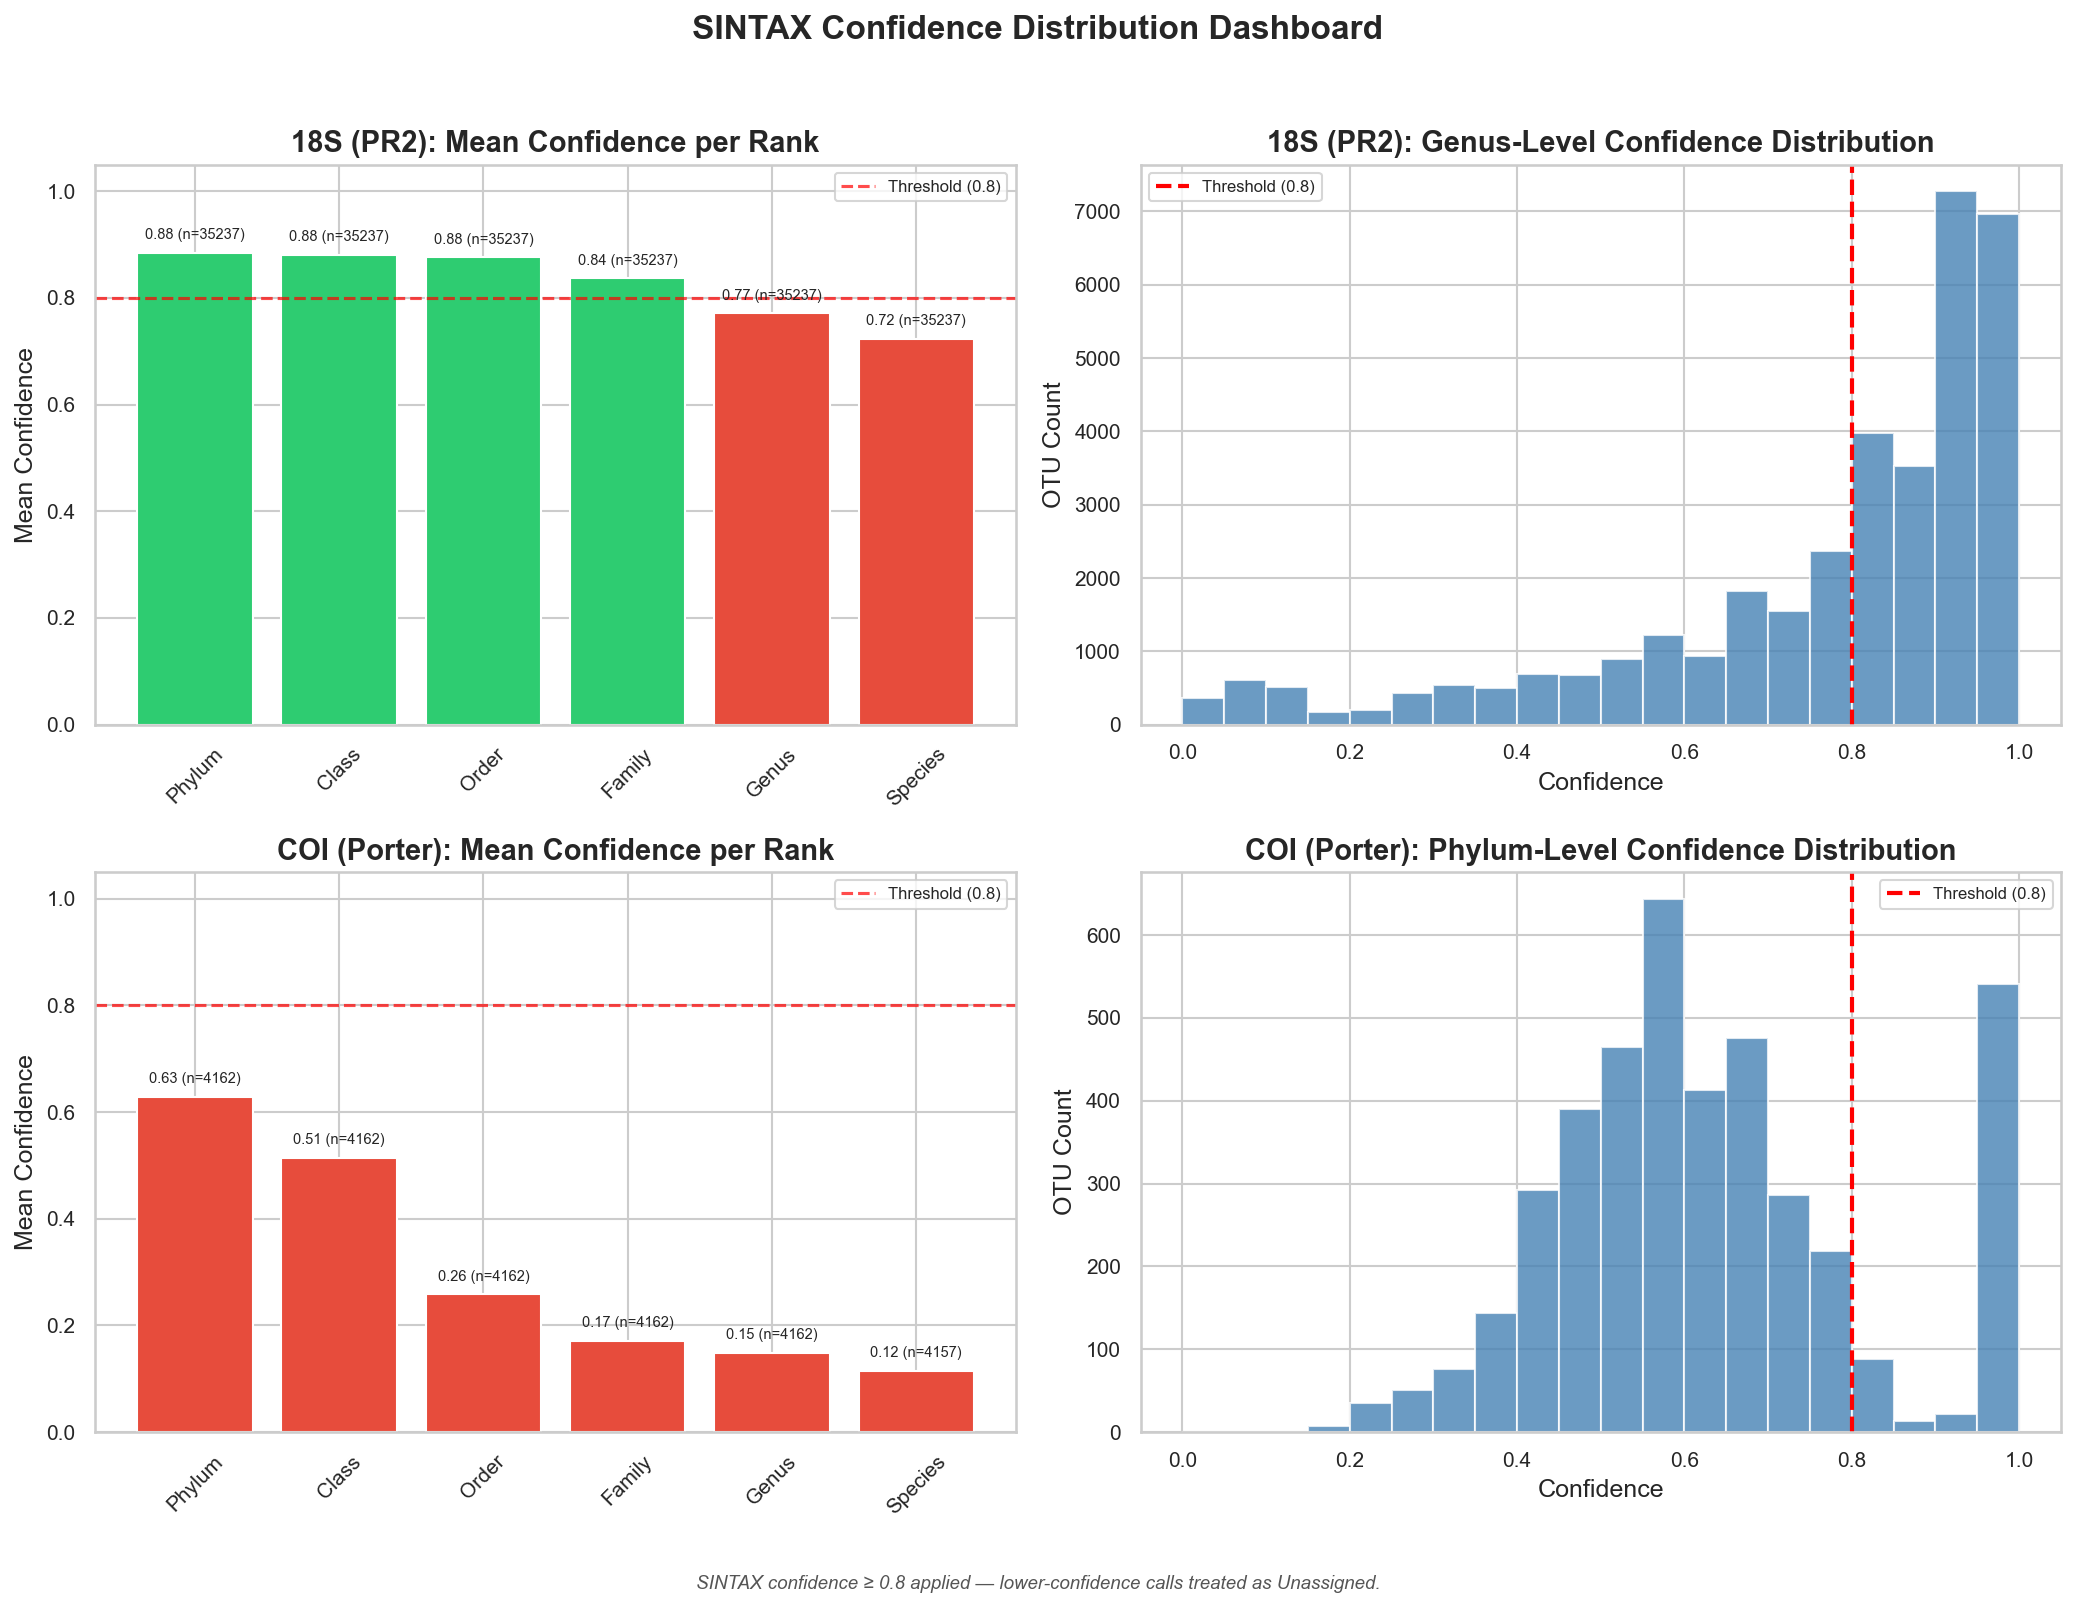

In [25]:
# === SINTAX Confidence Distribution Dashboard ===
ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

def plot_confidence_row(df, prefix, marker_label, axes):
    """Plot confidence metrics for one marker."""
    conf_cols = [f'{prefix}_{r}_Conf' for r in ranks]
    existing = [c for c in conf_cols if c in df.columns]
    if not existing:
        for ax in axes:
            ax.text(0.5, 0.5, 'No confidence columns found.\nRegenerate with:\nbash scripts/regenerate_taxonomy.sh',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
            ax.set_title(marker_label)
        return

    means, counts = [], []
    for r in ranks:
        col = f'{prefix}_{r}_Conf'
        if col in df.columns:
            vals = pd.to_numeric(df[col], errors='coerce').dropna()
            means.append(vals.mean() if len(vals) > 0 else 0)
            counts.append(len(vals))
        else:
            means.append(0)
            counts.append(0)

    ax1 = axes[0]
    colors = ['#2ecc71' if m >= 0.8 else '#e74c3c' for m in means]
    bars = ax1.bar(ranks, means, color=colors, edgecolor='white')
    ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Threshold (0.8)')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Mean Confidence')
    ax1.set_title(f'{marker_label}: Mean Confidence per Rank', fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)
    for bar, m, n in zip(bars, means, counts):
        if m > 0:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{m:.2f} (n={n})', ha='center', va='bottom', fontsize=7)

    hist_rank = 'Genus' if prefix == 'PR2' else 'Phylum'
    hist_col = f'{prefix}_{hist_rank}_Conf'
    ax2 = axes[1]
    if hist_col in df.columns:
        vals = pd.to_numeric(df[hist_col], errors='coerce').dropna()
        if len(vals) > 0:
            ax2.hist(vals, bins=20, range=(0, 1), color='steelblue', edgecolor='white', alpha=0.8)
            ax2.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Threshold (0.8)')
            ax2.set_xlabel('Confidence')
            ax2.set_ylabel('OTU Count')
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence Distribution', fontweight='bold')
            ax2.legend(fontsize=8)
        else:
            ax2.text(0.5, 0.5, f'No {hist_rank} confidence values',
                    ha='center', va='center', transform=ax2.transAxes)
            ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, f'Column {hist_col} not found',
                ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{marker_label}: {hist_rank}-Level Confidence', fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SINTAX Confidence Distribution Dashboard', fontsize=16, fontweight='bold', y=1.02)

plot_confidence_row(df_18s, prefix_18s, f'18S ({prefix_18s})', axes[0])
plot_confidence_row(df_coi_raw, prefix_coi, f'COI ({prefix_coi})', axes[1])

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

## Database Performance Dashboard

Evaluate how well the reference database classifies our OTUs. Three diagnostic panels per marker:

1. **OTUs classified per rank** — What fraction of OTUs gets any assignment (gray) vs a *confident* assignment (green, ≥ 0.8) at each rank. Shows **coverage breadth + quality**.
2. **Reads covered per rank** — Same but weighted by read abundance. A DB could classify few OTUs that nonetheless represent most reads (or the opposite).
3. **Deepest confident rank** — For each OTU, the deepest rank it reached confidently. Shows the **resolution power** of the DB for this dataset.

Good DB for this marker = high green bars + reads-covered high + most OTUs reaching Genus/Species.

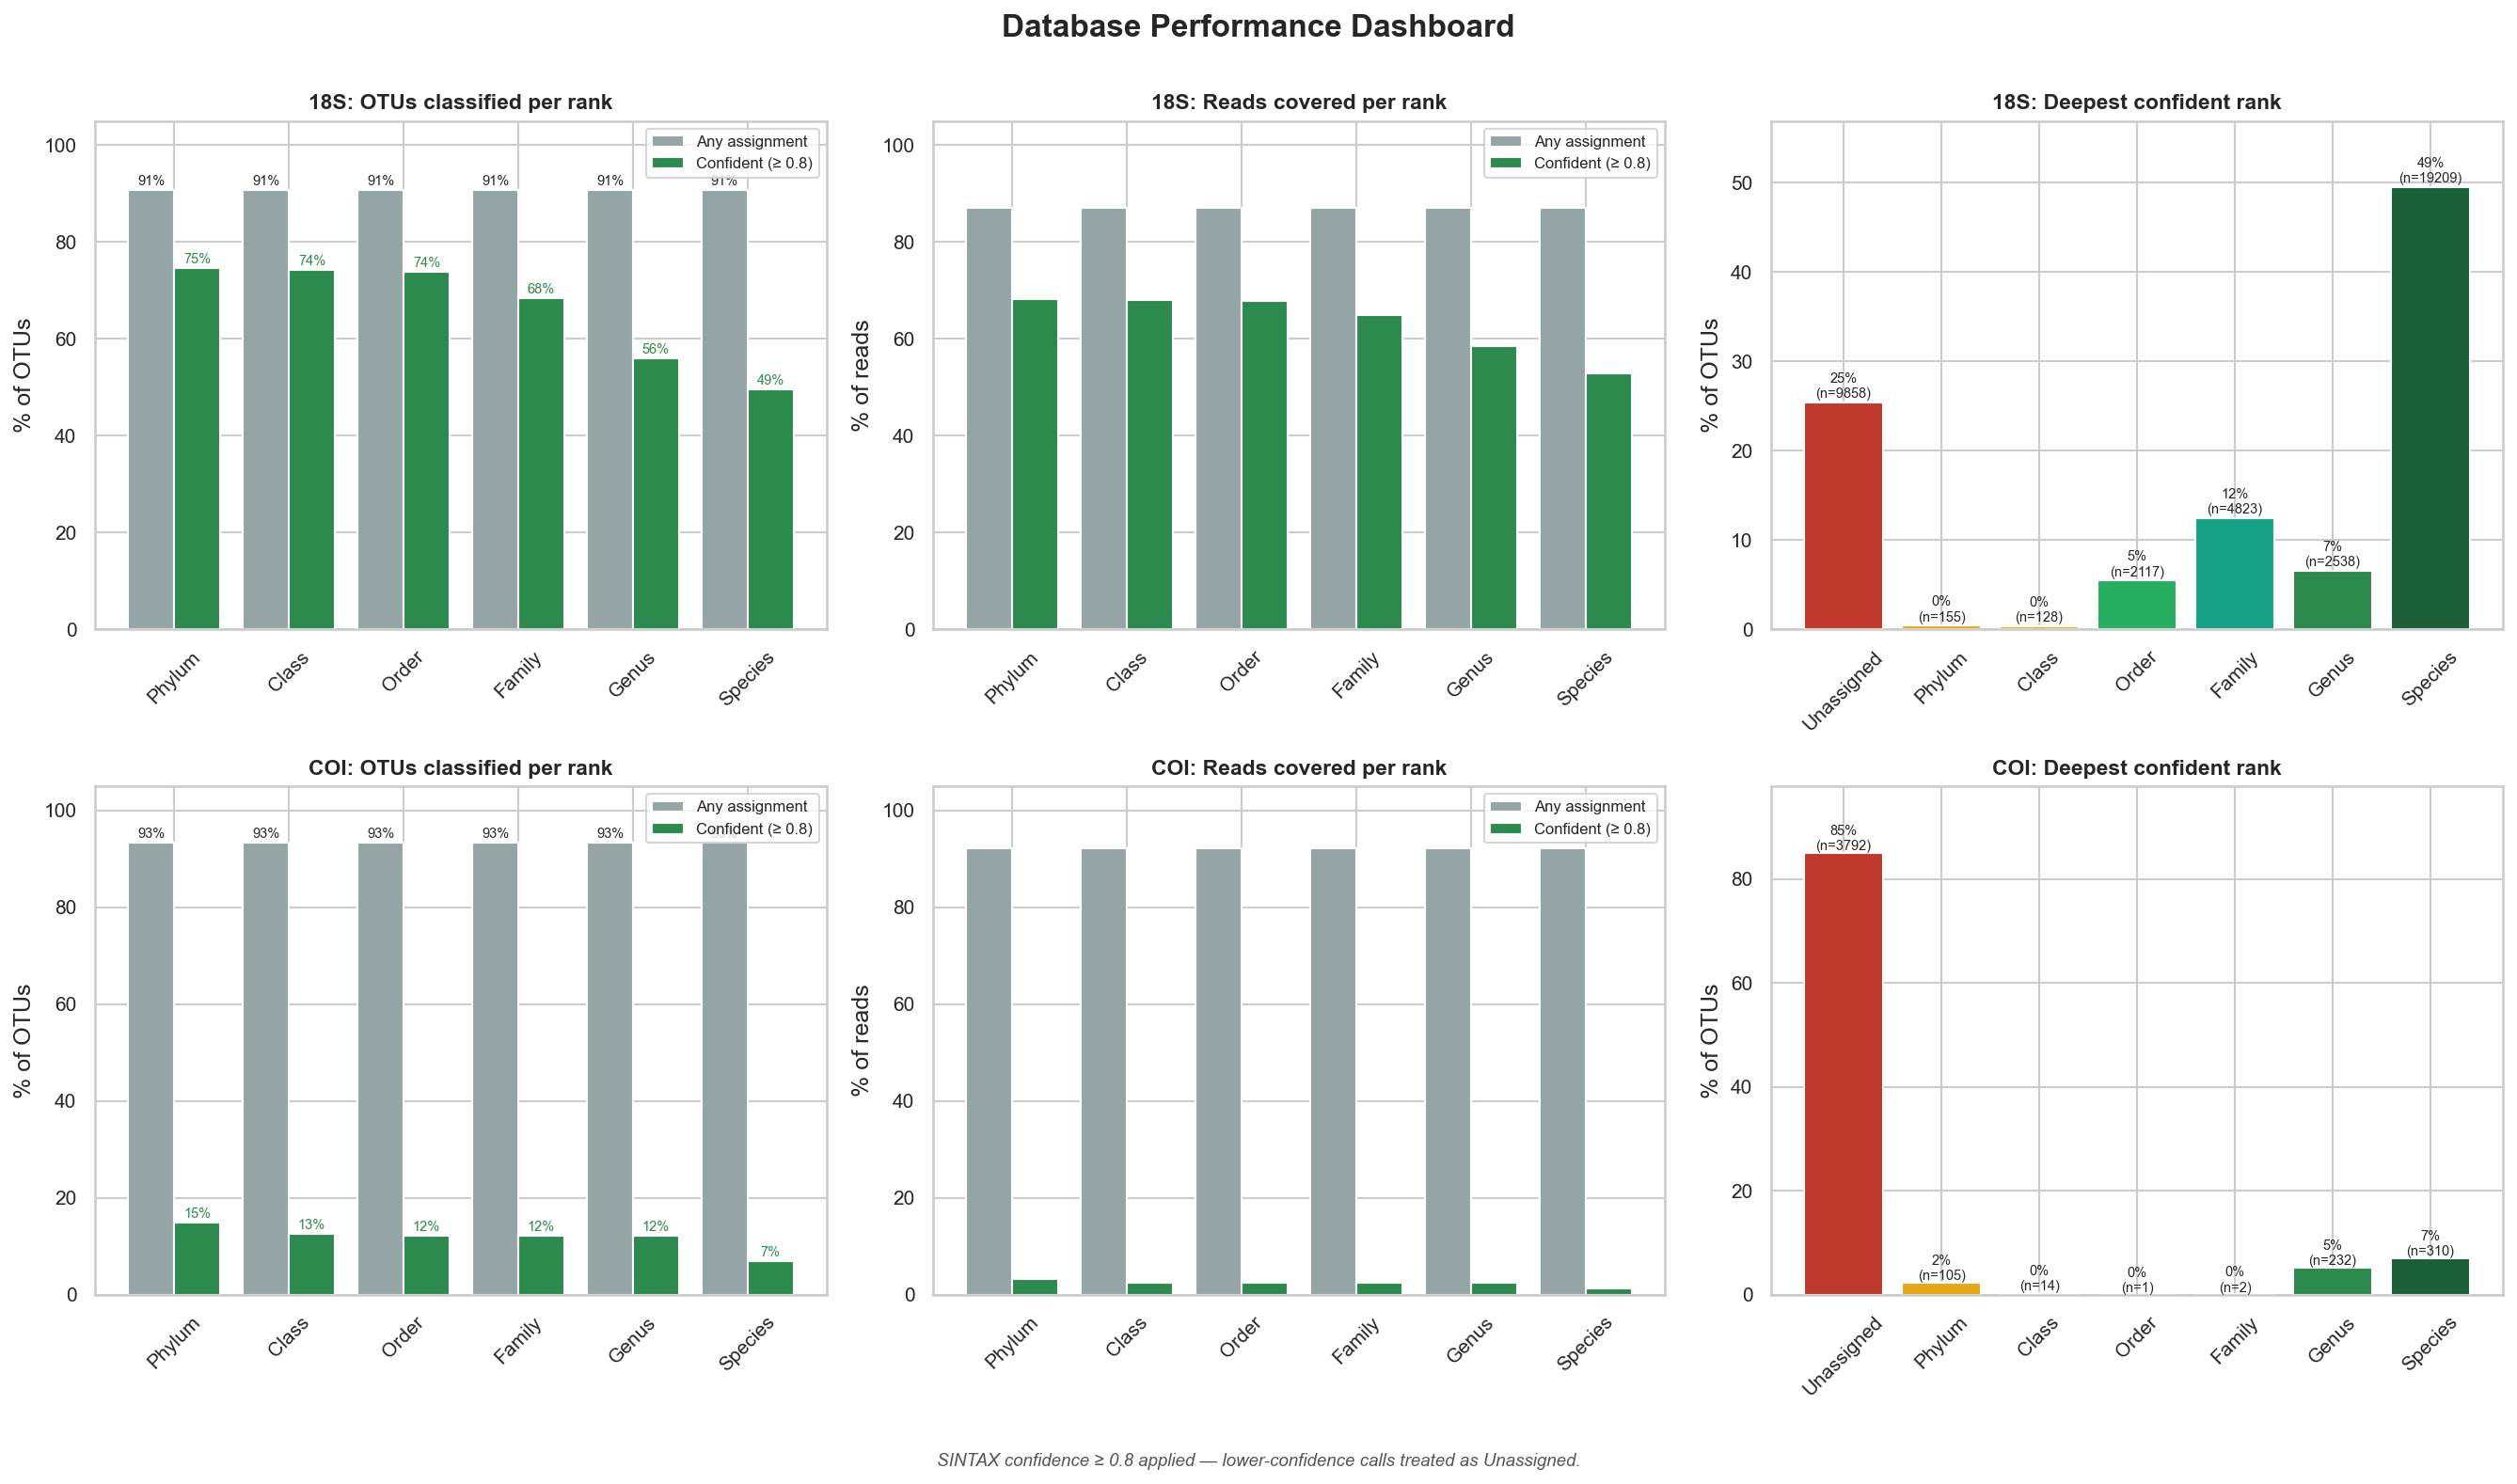


DATABASE PERFORMANCE SUMMARY

18S  (DB: PR2)
  Rank         % OTUs any    % OTUs conf   % reads conf
  Phylum            90.8%          74.6%          68.1%
  Class             90.8%          74.2%          68.0%
  Order             90.8%          73.9%          67.9%
  Family            90.8%          68.4%          65.0%
  Genus             90.8%          56.0%          58.5%
  Species           90.8%          49.5%          52.8%

COI  (DB: Porter)
  Rank         % OTUs any    % OTUs conf   % reads conf
  Phylum            93.4%          14.9%           3.2%
  Class             93.4%          12.5%           2.5%
  Order             93.4%          12.2%           2.4%
  Family            93.4%          12.2%           2.4%
  Genus             93.4%          12.2%           2.4%
  Species           93.3%           7.0%           1.3%


In [26]:
# Database Performance Dashboard
# Shows how well the reference DB classifies our OTUs: assignment rate per rank,
# confident-assignment rate, read-weighted coverage, and resolution depth.

ranks = ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
marker_data = [(df_18s, prefix_18s, '18S'), (df_coi_raw, prefix_coi, 'COI')]

def db_stats(df, prefix):
    """Return per-rank stats for a marker."""
    stats = {'rank': [], 'pct_any': [], 'pct_conf': [],
             'pct_reads_any': [], 'pct_reads_conf': []}
    total_otus = len(df)
    total_reads = df['Total_Abundance'].sum() if 'Total_Abundance' in df.columns else df[[c for c in df.columns if c.startswith('Sample_')]].sum().sum()
    for rank in ranks:
        col = f'{prefix}_{rank}'
        conf_col = f'{prefix}_{rank}_Conf'
        if col not in df.columns:
            continue
        has_any = ~df[col].isin(['Unassigned', '', None]) & df[col].notna()
        if conf_col in df.columns:
            conf_vals = pd.to_numeric(df[conf_col], errors='coerce').fillna(0)
            has_conf = has_any & (conf_vals >= CONF_THRESHOLD)
        else:
            has_conf = has_any
        reads_col = 'Total_Abundance' if 'Total_Abundance' in df.columns else None
        if reads_col:
            reads_any = df.loc[has_any, reads_col].sum()
            reads_conf = df.loc[has_conf, reads_col].sum()
        else:
            sample_cols = [c for c in df.columns if c.startswith('Sample_')]
            reads_any = df.loc[has_any, sample_cols].sum().sum()
            reads_conf = df.loc[has_conf, sample_cols].sum().sum()
        stats['rank'].append(rank)
        stats['pct_any'].append(100 * has_any.sum() / total_otus)
        stats['pct_conf'].append(100 * has_conf.sum() / total_otus)
        stats['pct_reads_any'].append(100 * reads_any / total_reads if total_reads > 0 else 0)
        stats['pct_reads_conf'].append(100 * reads_conf / total_reads if total_reads > 0 else 0)
    return stats

def resolution_depth(df, prefix):
    """For each OTU, find deepest confident rank. Returns counts per rank + Unassigned."""
    depths = {'Unassigned': 0}
    for r in ranks:
        depths[r] = 0
    for _, row in df.iterrows():
        deepest = 'Unassigned'
        for rank in ranks:
            col = f'{prefix}_{rank}'
            conf_col = f'{prefix}_{rank}_Conf'
            if col not in df.columns:
                continue
            val = row.get(col, '')
            if pd.isna(val) or val in ('Unassigned', ''):
                continue
            if conf_col in df.columns:
                try:
                    if float(row.get(conf_col, 0) or 0) >= CONF_THRESHOLD:
                        deepest = rank
                except (ValueError, TypeError):
                    pass
            else:
                deepest = rank
        depths[deepest] += 1
    return depths

# Build figure: one row per marker, 3 subplots per row
n_markers = len(marker_data)
fig, axes = plt.subplots(n_markers, 3, figsize=(18, 5 * n_markers))
if n_markers == 1:
    axes = axes.reshape(1, -1)

fig.suptitle('Database Performance Dashboard', fontsize=16, fontweight='bold', y=1.00)

for row_idx, (df, prefix, label) in enumerate(marker_data):
    s = db_stats(df, prefix)
    x = np.arange(len(s['rank']))
    width = 0.4

    # --- Panel 1: OTU-based assignment rate ---
    ax = axes[row_idx, 0]
    ax.bar(x - width/2, s['pct_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: OTUs classified per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    for xi, (a, c) in enumerate(zip(s['pct_any'], s['pct_conf'])):
        ax.text(xi - width/2, a + 1, f'{a:.0f}%', ha='center', fontsize=7)
        ax.text(xi + width/2, c + 1, f'{c:.0f}%', ha='center', fontsize=7, color='#2d8a4e')

    # --- Panel 2: Read-weighted assignment rate ---
    ax = axes[row_idx, 1]
    ax.bar(x - width/2, s['pct_reads_any'], width, color='#95a5a6', label='Any assignment')
    ax.bar(x + width/2, s['pct_reads_conf'], width, color='#2d8a4e', label=f'Confident (\u2265 {CONF_THRESHOLD})')
    ax.set_xticks(x)
    ax.set_xticklabels(s['rank'], rotation=45)
    ax.set_ylabel('% of reads')
    ax.set_ylim(0, 105)
    ax.set_title(f'{label}: Reads covered per rank', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)

    # --- Panel 3: Resolution depth ---
    ax = axes[row_idx, 2]
    depths = resolution_depth(df, prefix)
    labels_d = ['Unassigned'] + ranks
    counts_d = [depths.get(l, 0) for l in labels_d]
    total_d = sum(counts_d)
    pcts_d = [100 * c / total_d if total_d > 0 else 0 for c in counts_d]
    colors_d = ['#c0392b'] + ['#e6a817', '#f39c12', '#27ae60', '#16a085', '#2d8a4e', '#1a5f37']
    bars = ax.bar(labels_d, pcts_d, color=colors_d)
    ax.set_ylabel('% of OTUs')
    ax.set_ylim(0, max(pcts_d) * 1.15 if pcts_d else 100)
    ax.set_title(f'{label}: Deepest confident rank', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=45)
    for xi, (p, c) in enumerate(zip(pcts_d, counts_d)):
        ax.text(xi, p + 0.5, f'{p:.0f}%\n(n={c})', ha='center', fontsize=7)

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

# Print summary table
print("\n" + "=" * 70)
print("DATABASE PERFORMANCE SUMMARY")
print("=" * 70)
for df, prefix, label in marker_data:
    s = db_stats(df, prefix)
    print(f"\n{label}  (DB: {prefix})")
    print(f"  {'Rank':<10} {'% OTUs any':>12} {'% OTUs conf':>14} {'% reads conf':>14}")
    for i, r in enumerate(s['rank']):
        print(f"  {r:<10} {s['pct_any'][i]:>11.1f}% {s['pct_conf'][i]:>13.1f}% {s['pct_reads_conf'][i]:>13.1f}%")


## Raw Read Length Distributions (Pre-Clustering)
Number of reads at each sequence length, aggregated across all barcodes for each marker. This reveals the actual abundance of reads by length before OTU clustering, highlighting primer dimers, truncated reads, or length biases in the sequencing run.

✓ 18S: 226,443 reads, median=1857bp, range=1500-2799bp
✓ COI: 14,495 reads, median=834bp, range=500-900bp


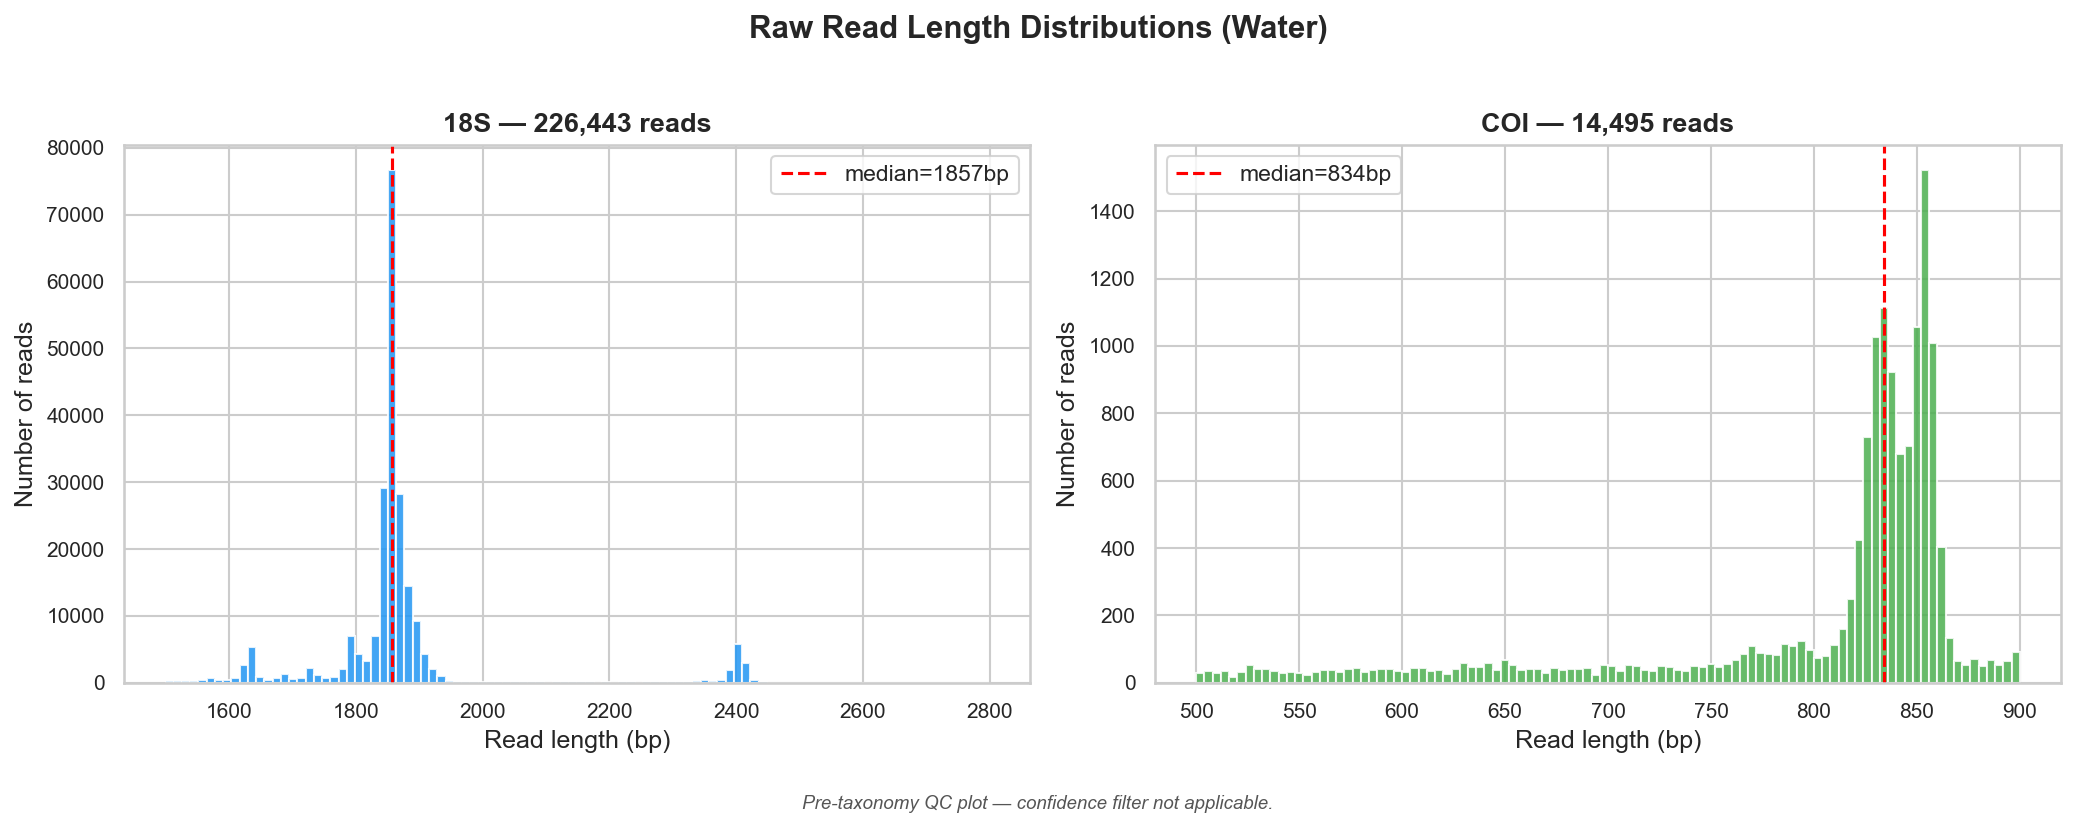

In [27]:
import gzip

# Collect raw read lengths per marker across all barcodes
barcode_dirs = sorted(BASE.glob("barcode*"))
marker_lengths = {"18S": [], "COI": []}
marker_colors_raw = {"18S": "#2196F3", "COI": "#4CAF50"}

for bd in barcode_dirs:
    for marker in marker_lengths:
        fq = bd / f"filtered_reads_{marker}.fastq.gz"
        if fq.exists():
            with gzip.open(str(fq), 'rt') as f:
                for i, line in enumerate(f):
                    if i % 4 == 1:  # sequence line
                        marker_lengths[marker].append(len(line.strip()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, lengths) in enumerate(marker_lengths.items()):
    ax = axes[i]
    if lengths:
        ax.hist(lengths, bins=100, color=marker_colors_raw[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths):,} reads", fontsize=13, fontweight="bold")
        ax.set_xlabel("Read length (bp)")
        ax.set_ylabel("Number of reads")
        ax.legend()
        print(f"✓ {marker}: {len(lengths):,} reads, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nNo reads found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Raw Read Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
add_conf_note(kind='qc')
plt.show()

## Consensus OTU Sequence Length Distributions
Length distributions of consensus OTU sequences for each marker. Useful for identifying primer dimers, truncated reads, or off-target amplification.

✓ 18S: 35237 OTUs, median=1853bp, range=1500-2809bp
✓ COI: 4162 OTUs, median=829bp, range=417-902bp


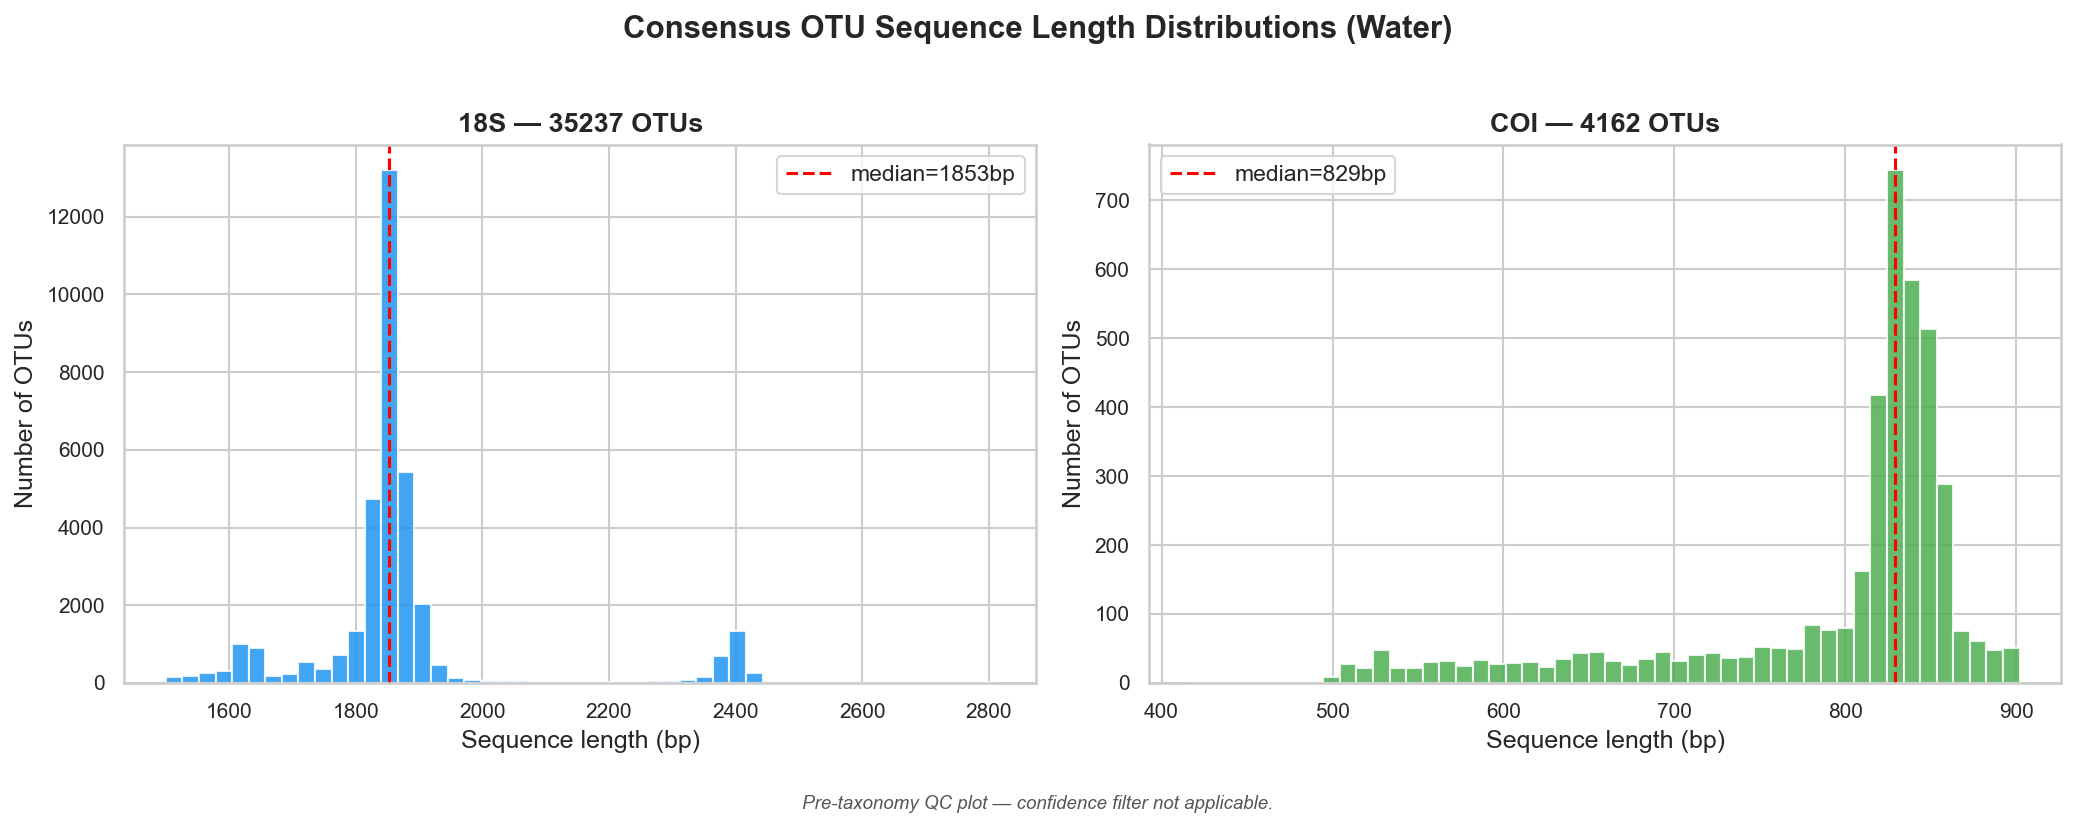

In [28]:
# Parse consensus FASTA files and plot sequence length distributions
fasta_files = {
    "18S": BASE / "temp_clustering/consensus_18S_clean.fasta",
    "COI": BASE / "temp_clustering/consensus_COI_clean.fasta",
}
marker_colors = {"18S": "#2196F3", "COI": "#4CAF50"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (marker, path) in enumerate(fasta_files.items()):
    ax = axes[i]
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        ax.hist(lengths, bins=50, color=marker_colors[marker], edgecolor="white", alpha=0.85)
        ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5,
                   label=f"median={np.median(lengths):.0f}bp")
        ax.set_title(f"{marker} — {len(lengths)} OTUs", fontsize=13, fontweight="bold")
        ax.set_xlabel("Sequence length (bp)")
        ax.set_ylabel("Number of OTUs")
        ax.legend()
        print(f"✓ {marker}: {len(lengths)} OTUs, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        ax.text(0.5, 0.5, f"{marker}\nFASTA not found", ha='center', va='center', transform=ax.transAxes)

plt.suptitle("Consensus OTU Sequence Length Distributions (Water)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
add_conf_note(kind='qc')
plt.show()

# Part A: 18S Marker Biodiversity Analysis (PR2)
*Objective: To characterize the planktonic community structure using the 18S marker with the PR2 database — the best-performing 18S database in our comparison.*

## A.1.a Broad Taxonomic Structure
This stacked bar chart visualizes the relative abundance of eukaryotic Phyla across all samples.
* **Expected Result:** High abundances of **Ciliophora** and **Arthropoda**, with better resolution than SILVA.
* **PR2 Advantage:** Many taxa that SILVA labels "Unassigned" should now have confident classifications.

[18S] Phylum: Unassigned = 32.3% of reads


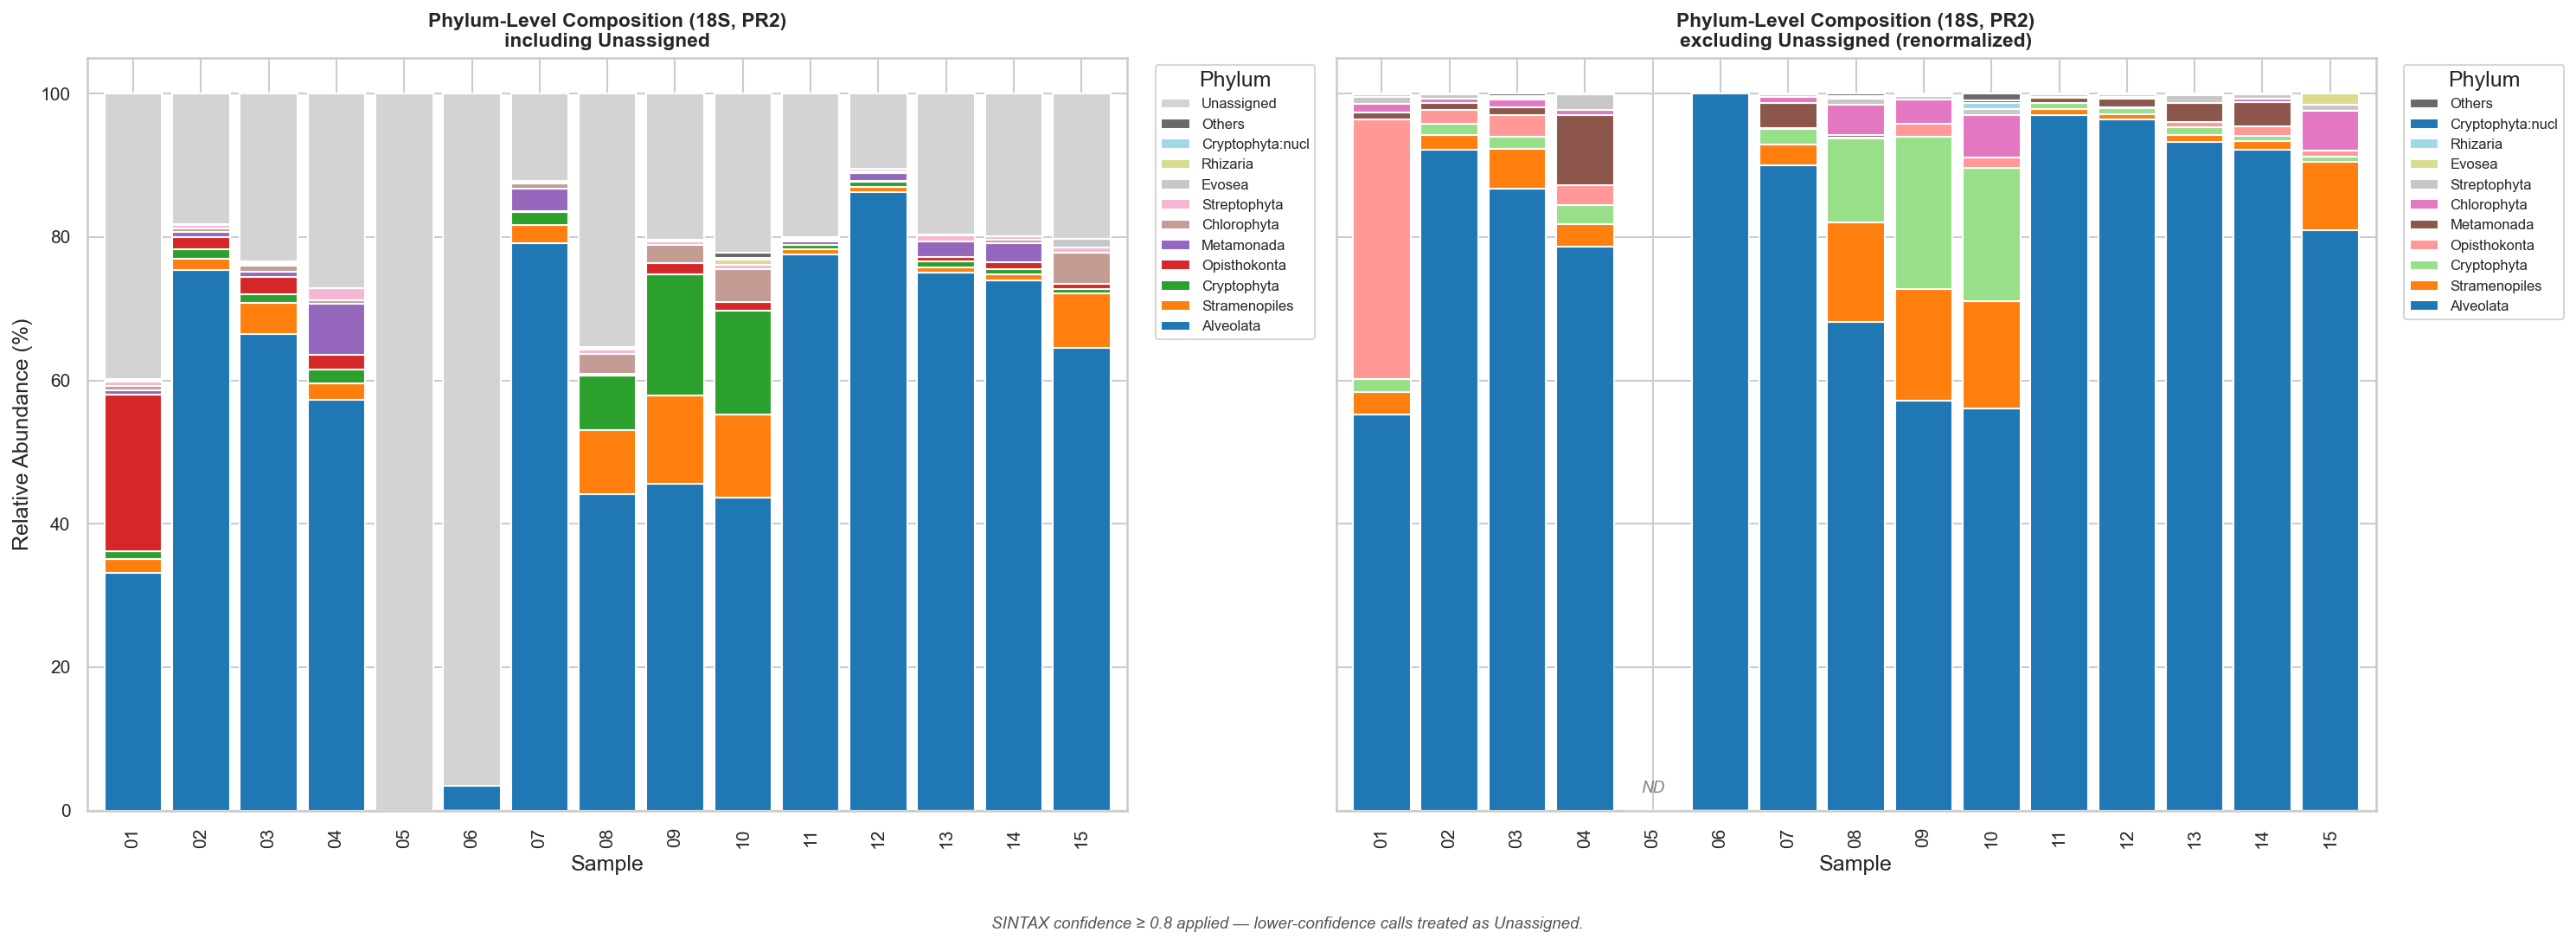

In [29]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Phylum', prefix_18s, '18S', sample_cols_18s, top_n=10)


## A.1.b Class-Level Breakdown (18S)
**Objective:** To see which specific biological Classes dominate within the broad Phyla.

**Visual Analysis:**
1.  **Intramacronucleata (Ciliates):** Expected dominant Class in lake water eDNA.
2.  **Insecta (Terrestrial Input):** Arthropod reads at the class level often trace to insects (pollen, runoff).
3.  **Branchiopoda (Zooplankton):** Includes *Daphnia* — validates aquatic sampling.

**Compare with SILVA notebook:** PR2 should provide more detailed ciliate classification at this level.

[18S] Class: Unassigned = 32.5% of reads


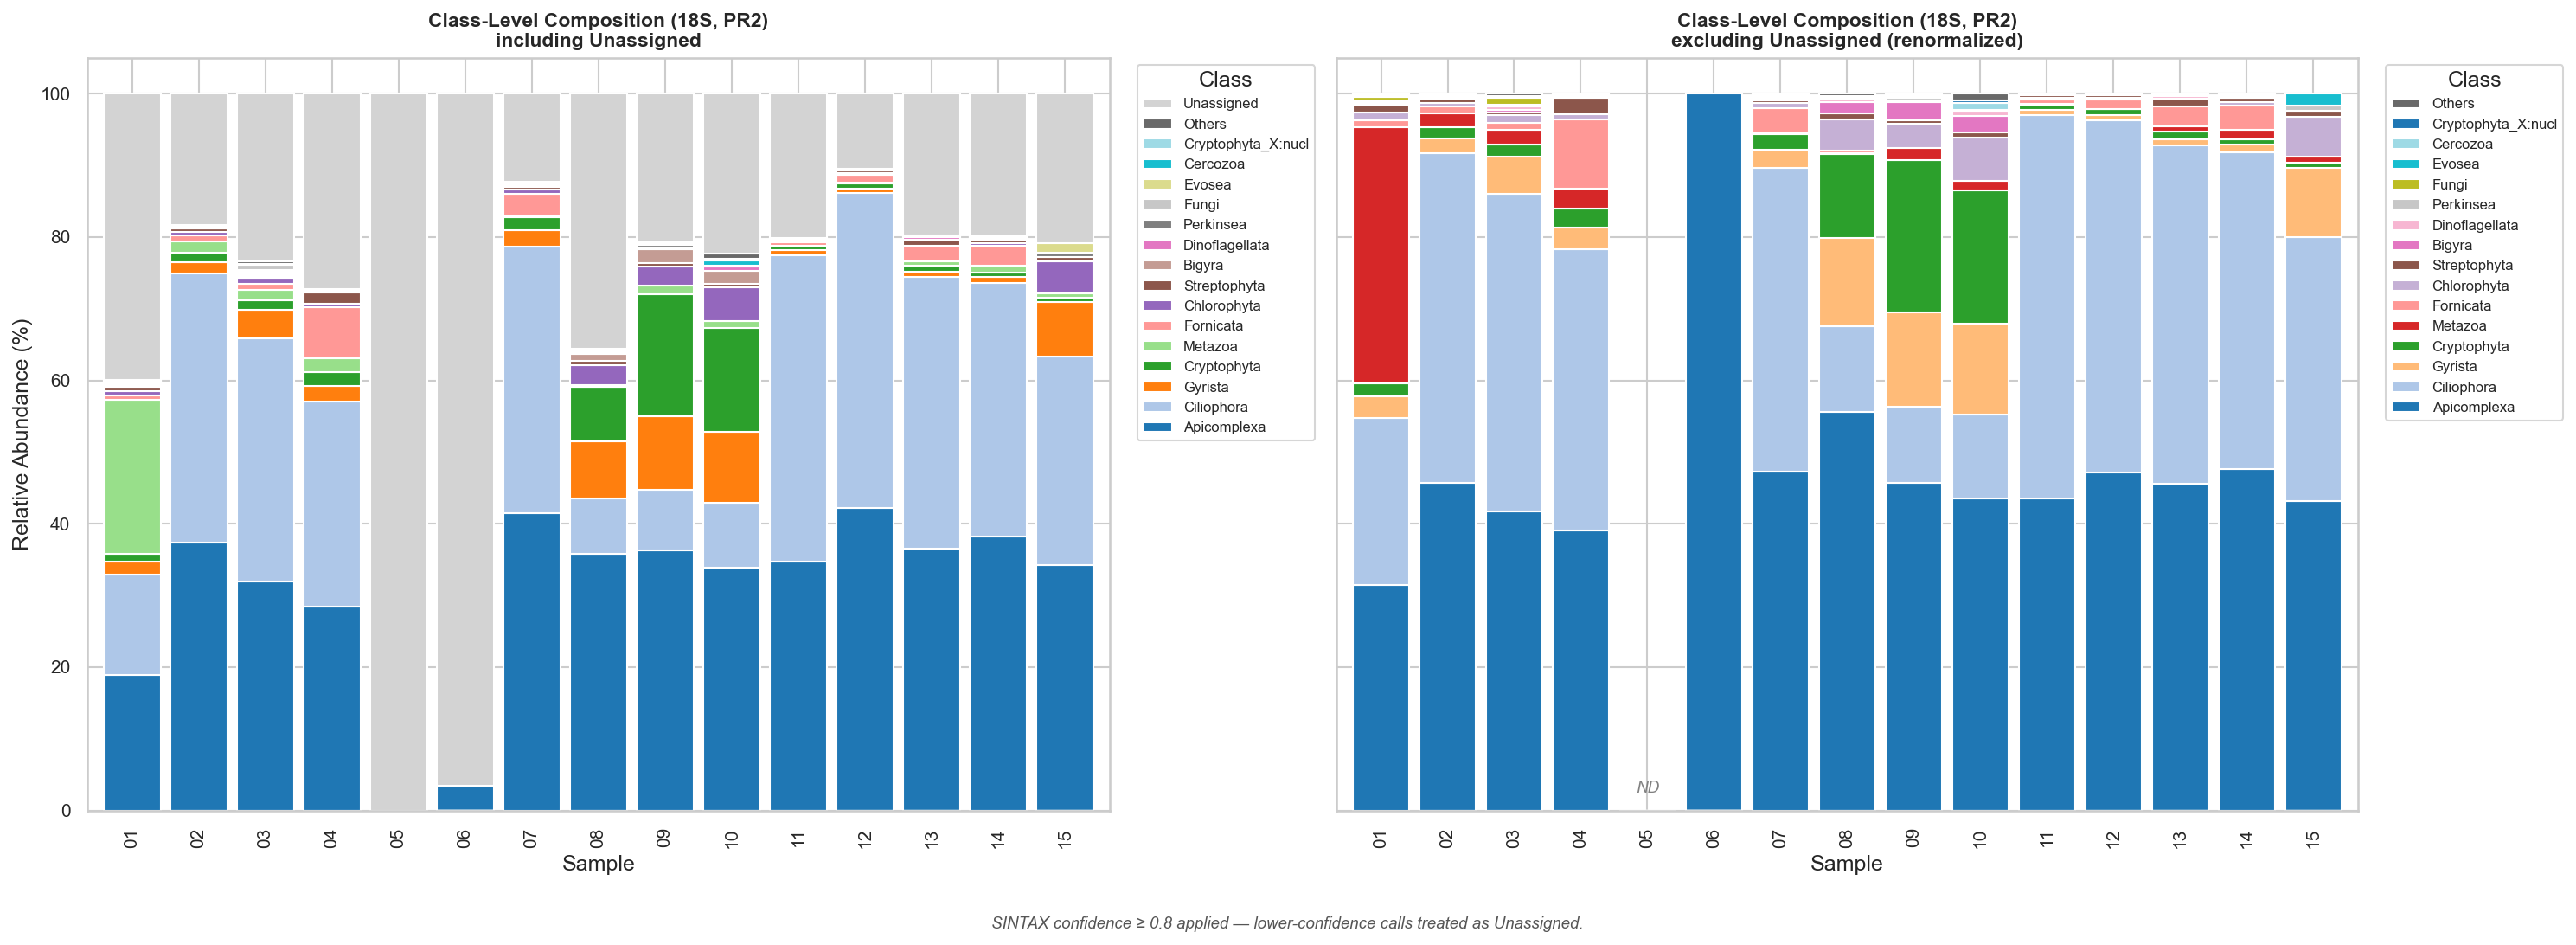

In [30]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Class', prefix_18s, '18S', sample_cols_18s, top_n=15)


## A.2 Order-Level Breakdown (18S)

[18S] Order: Unassigned = 32.6% of reads


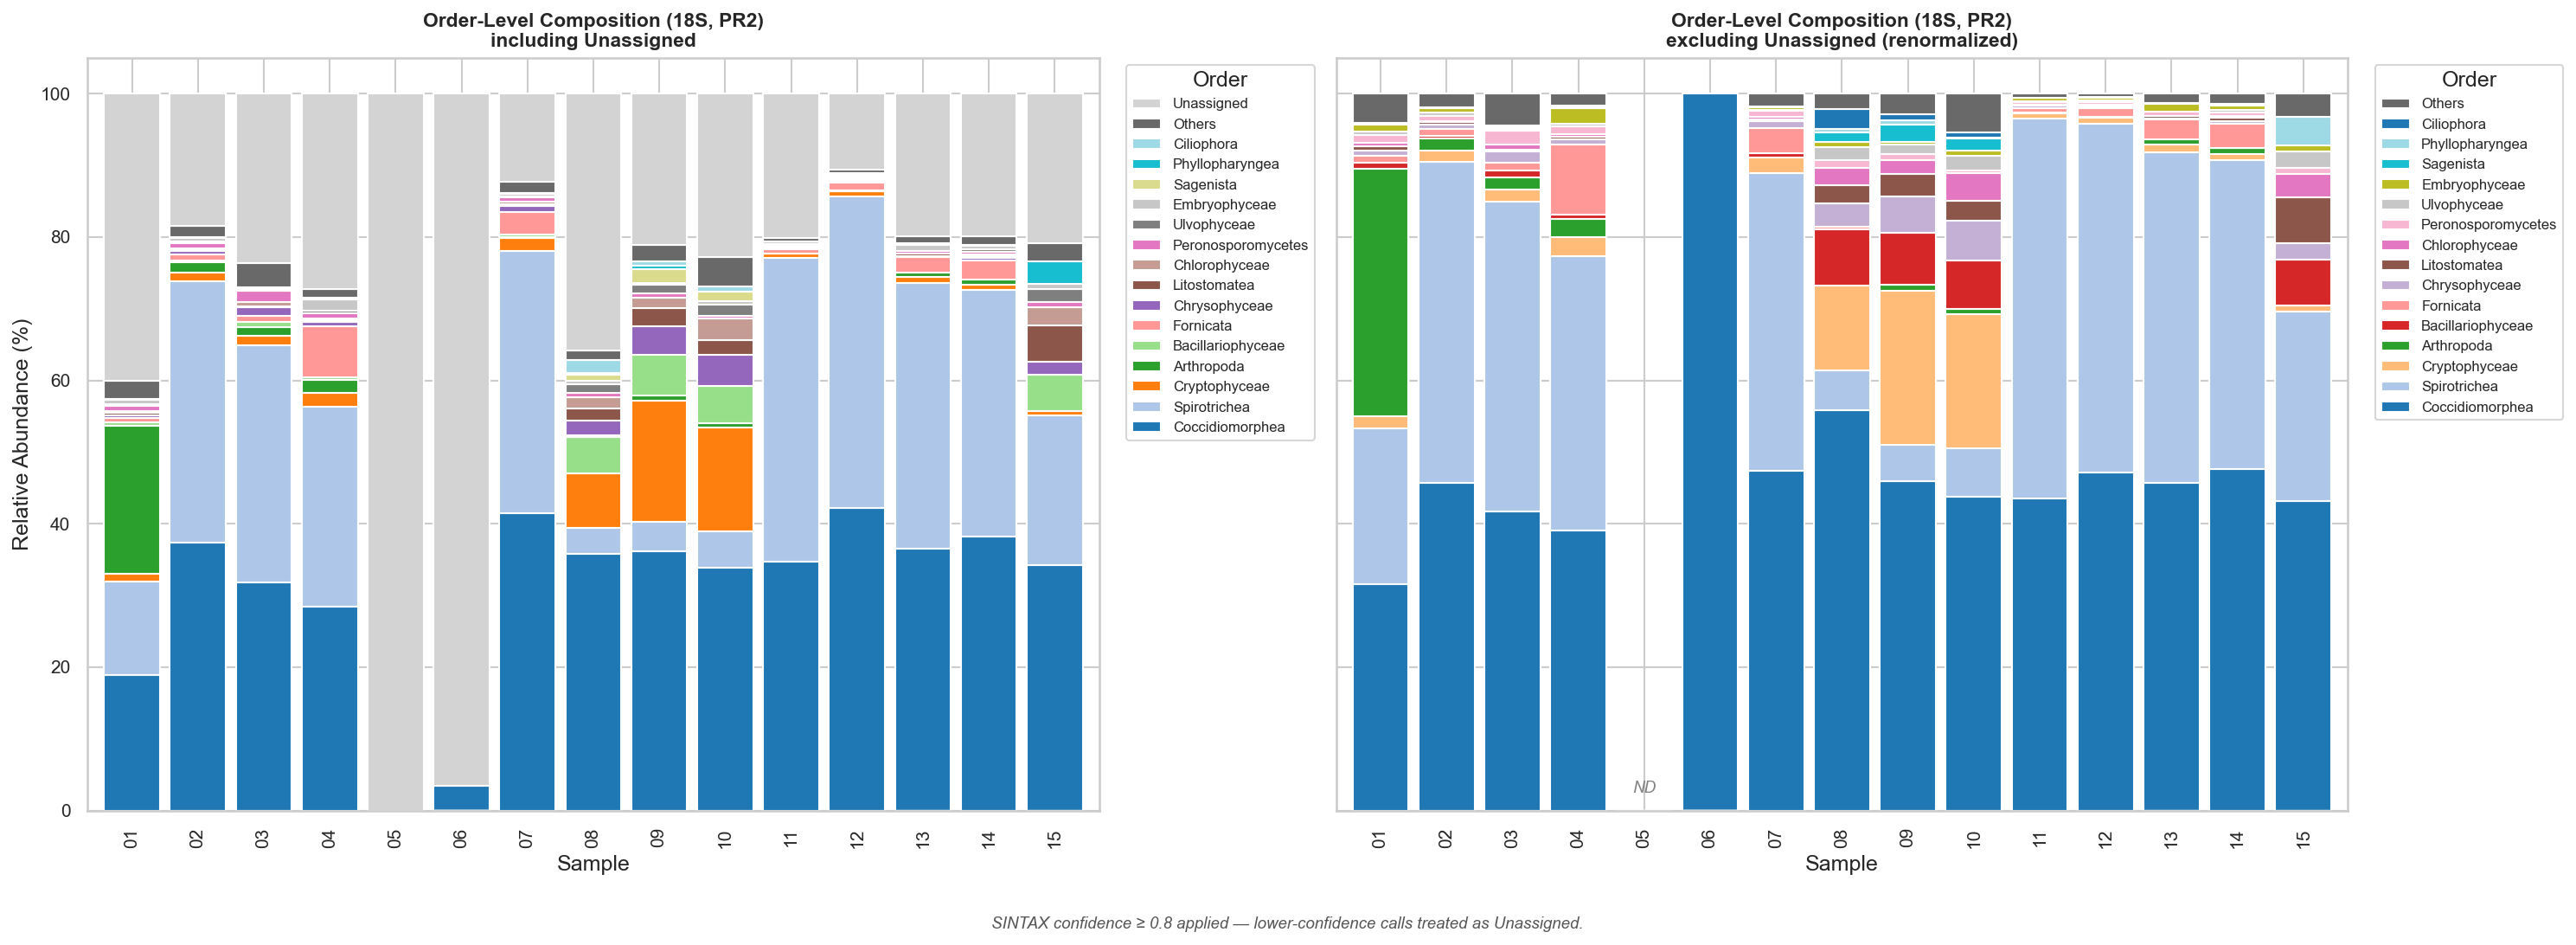

In [31]:
sample_cols_18s = [c for c in df_18s.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_18s, 'Order', prefix_18s, '18S', sample_cols_18s, top_n=15)


## A.3 Genus-Level Top 20 (18S)
Top genera detected by the 18S marker with confidence annotations.

C:\Users\ilias\AppData\Local\Temp\ipykernel_26400\1101311078.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)


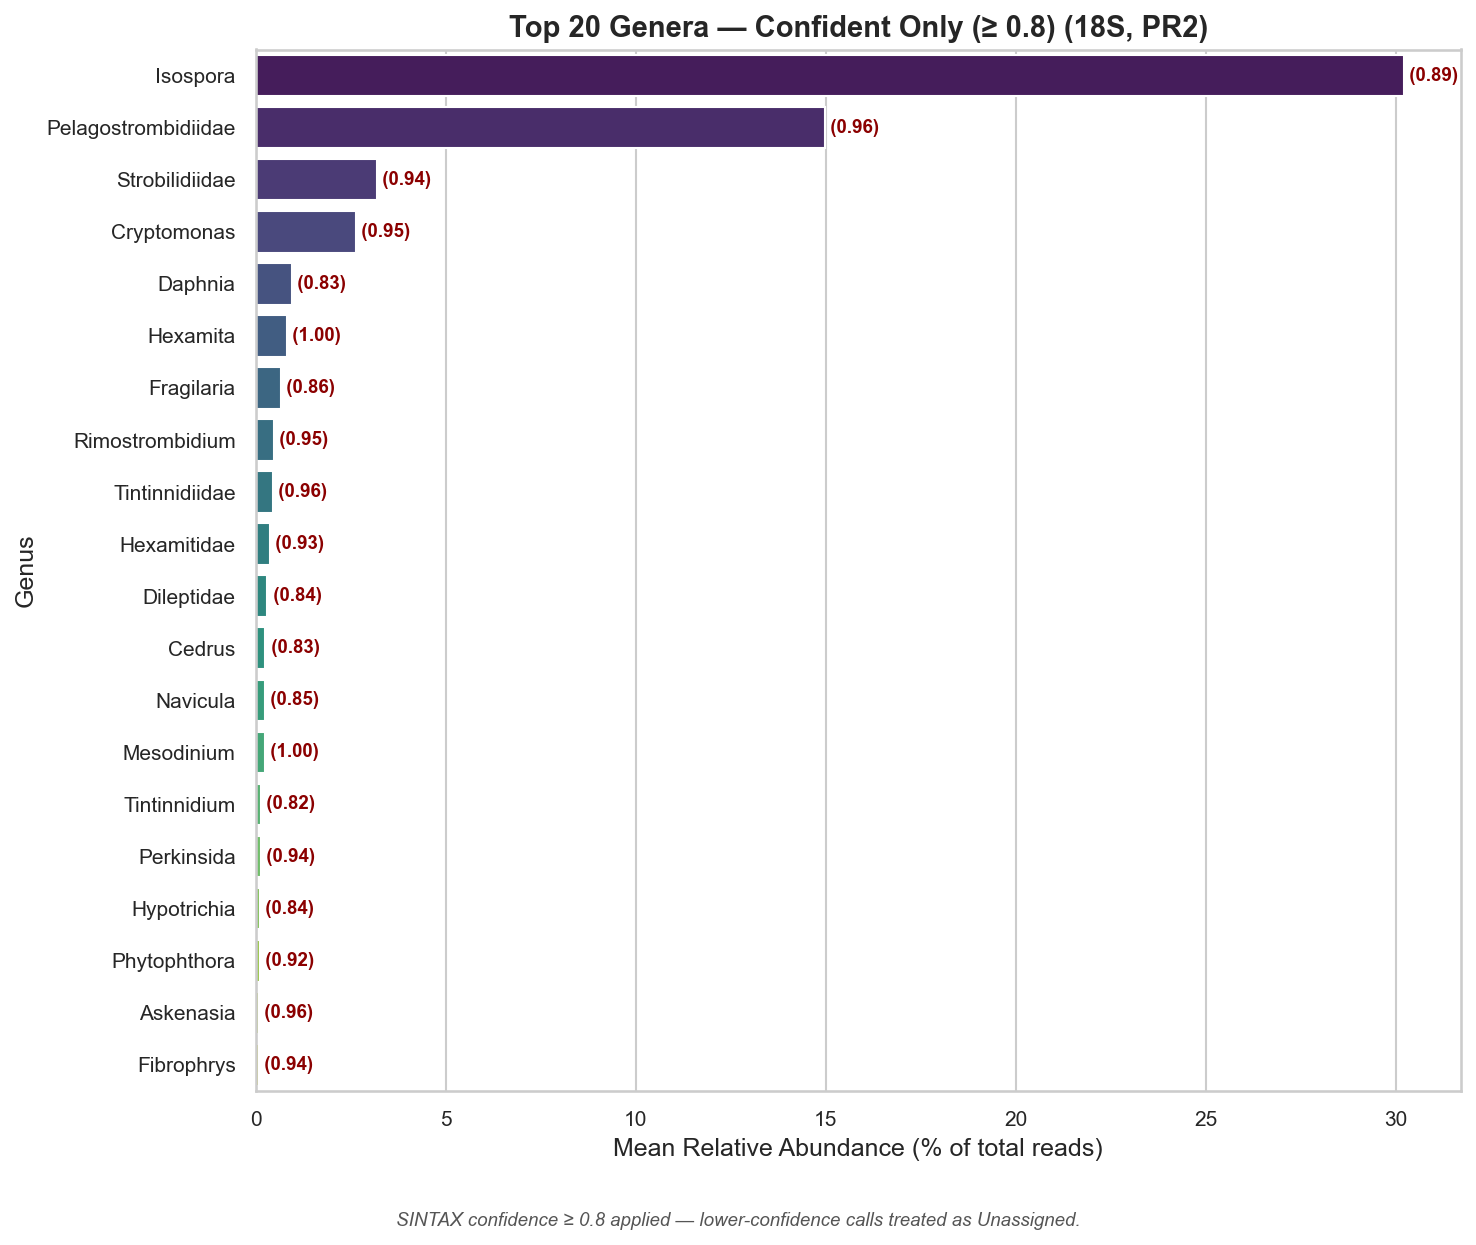

In [32]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_18s[genus_col] = df_18s[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_18s.columns:
    mask_conf = pd.to_numeric(df_18s[conf_col], errors='coerce') >= 0.8
    df_conf = df_18s[mask_conf].copy()
else:
    df_conf = df_18s[df_18s[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_18s].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.div(df_18s[sample_cols_18s].sum(axis=0), axis=1).mean(axis=1) * 100
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (18S, {prefix_18s})', fontweight='bold')
ax.set_xlabel('Mean Relative Abundance (% of total reads)')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

### Top 20 Genera by Abundance — All Confidences (18S)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

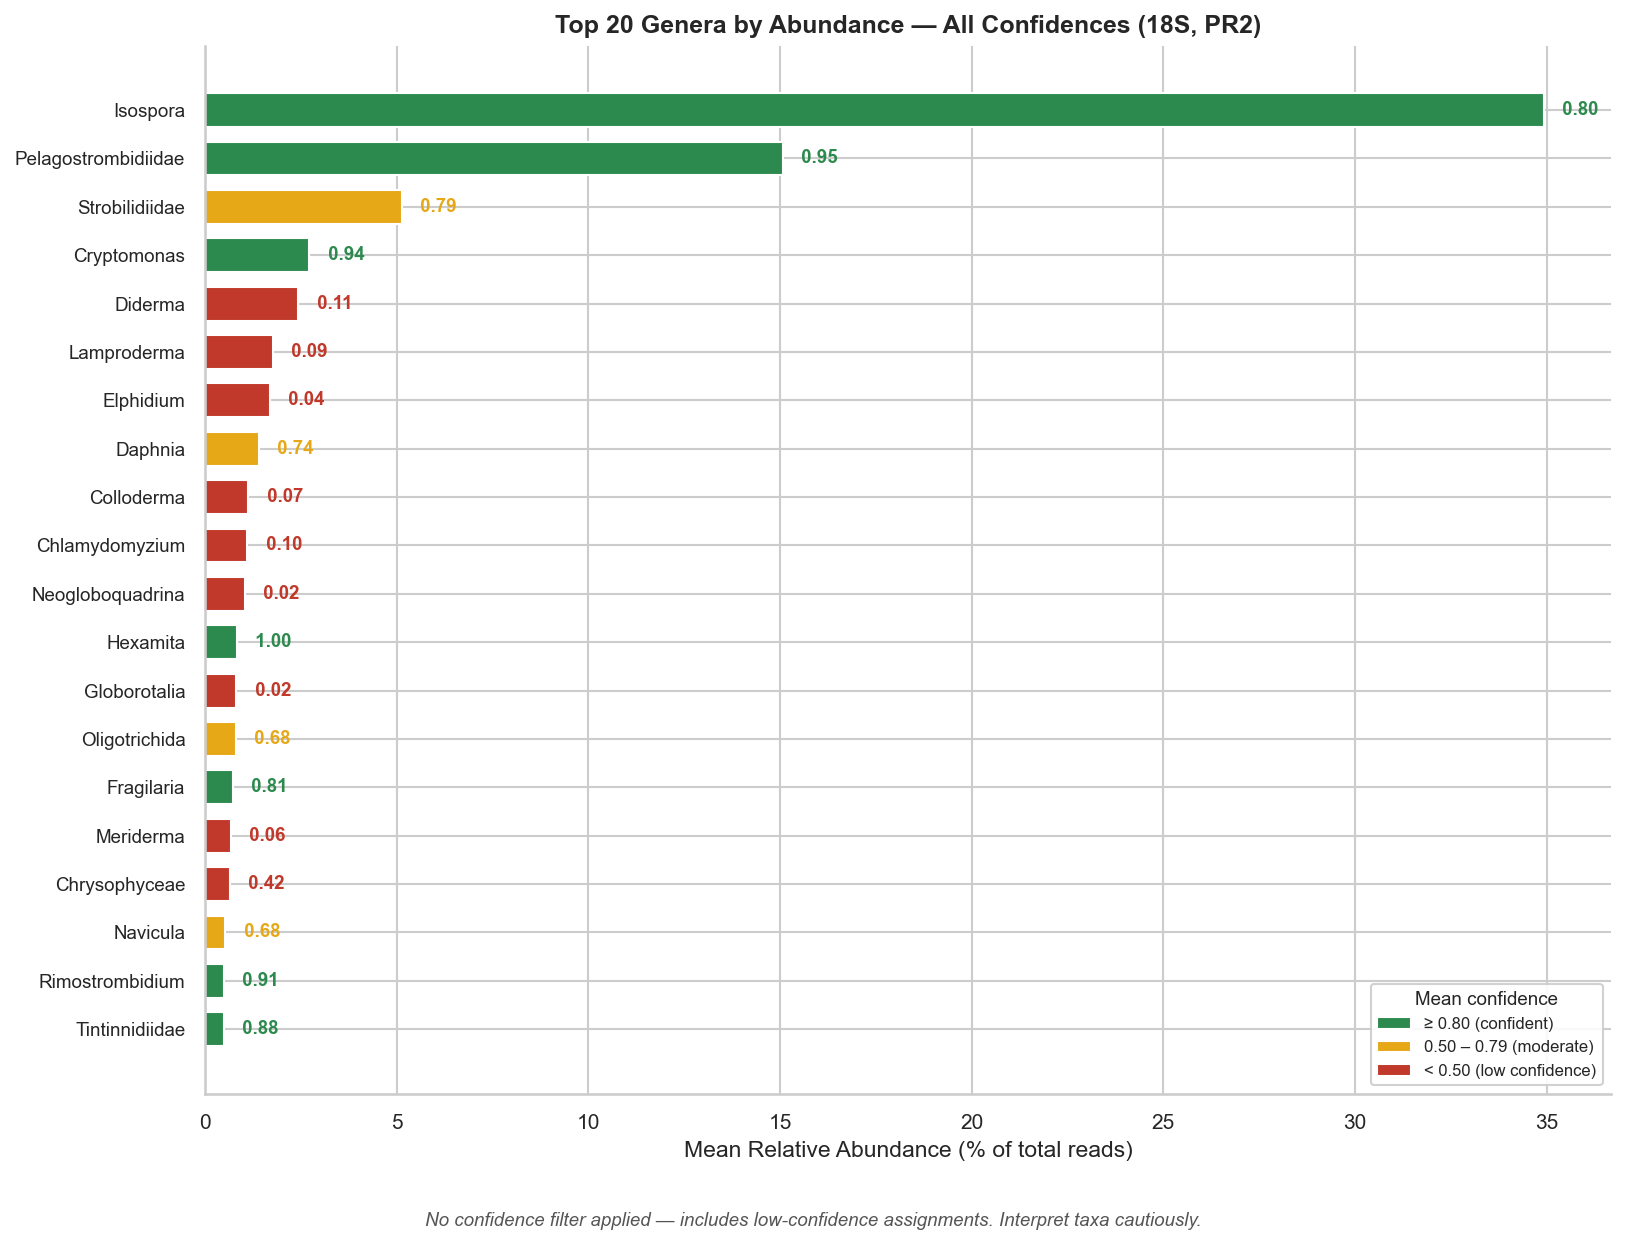

In [33]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_18s}_Genus'
conf_col = f'{prefix_18s}_Genus_Conf'
df_tmp = df_18s.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_18s].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.div(df_18s[sample_cols_18s].sum(axis=0), axis=1).mean(axis=1) * 100
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Mean Relative Abundance (% of total reads)', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (18S, {prefix_18s})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
add_conf_note(kind='unfiltered')
plt.show()

## A.3b Top 20 Eukaryotic Genera (18S, PR2)
Filtered to **Eukaryota domain only** with **confidence >= 0.8**. PR2 may assign some OTUs to Archaea — this filter ensures only eukaryotic genera are shown.

Eukaryota filter: 35234/38828 OTUs (90.7%)


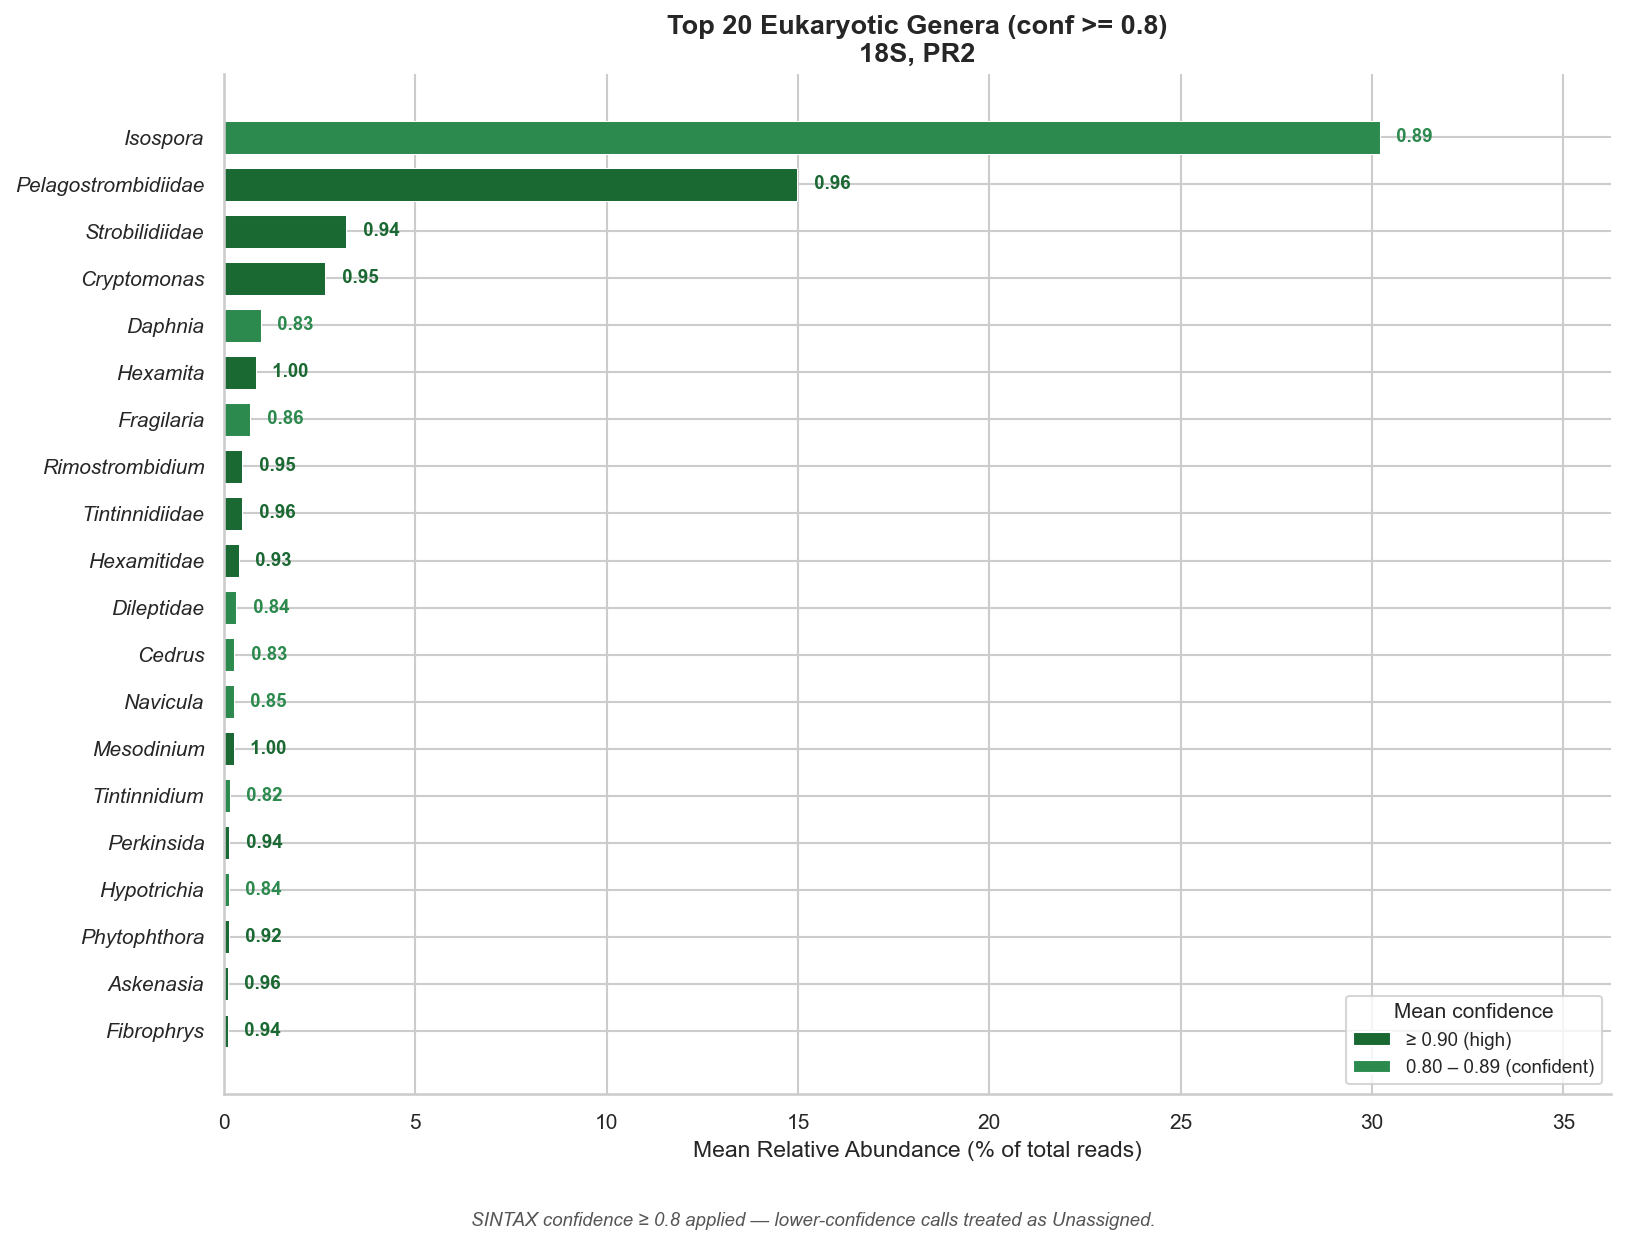


Top 5 Eukaryotic genera (18S, PR2):
  Isospora: 30.20 % mean abundance (conf 0.89)
  Pelagostrombidiidae: 14.98 % mean abundance (conf 0.96)
  Strobilidiidae: 3.19 % mean abundance (conf 0.94)
  Cryptomonas: 2.64 % mean abundance (conf 0.95)
  Daphnia: 0.96 % mean abundance (conf 0.83)


In [34]:
# Top 20 Genera — Eukaryota only, confidence >= 0.8
_df = df_18s.copy()
_prefix = prefix_18s
_genus_col = f'{_prefix}_Genus'
_conf_col = f'{_prefix}_Genus_Conf'
_domain_col = f'{_prefix}_Domain'

# Filter: Eukaryota domain only
if _domain_col in _df.columns:
    _euk_mask = _df[_domain_col].astype(str).str.contains('Eukaryota', case=False, na=False)
    _df = _df[_euk_mask].copy()
    _n_total = len(df_18s)
    _n_euk = len(_df)
    print(f"Eukaryota filter: {_n_euk}/{_n_total} OTUs ({100*_n_euk/_n_total:.1f}%)")
else:
    print(f"No Domain column found ({_domain_col}), using all OTUs")

# Filter: confidence >= 0.8
_df[_genus_col] = _df[_genus_col].fillna('Unassigned')
if _conf_col in _df.columns:
    _conf_mask = pd.to_numeric(_df[_conf_col], errors='coerce') >= CONF_THRESHOLD
    _df = _df[_conf_mask].copy()

# Aggregate by genus
_genus_agg = _df.groupby(_genus_col)[sample_cols_18s].sum()
_genus_agg = _genus_agg.drop('Unassigned', errors='ignore')
_genus_agg['Total'] = _genus_agg.div(df_18s[sample_cols_18s].sum(axis=0), axis=1).mean(axis=1) * 100
_genus_agg = _genus_agg.sort_values('Total', ascending=False)
_top20 = _genus_agg.head(20)

if len(_top20) == 0:
    print("No Eukaryota genera found with confidence >= 0.8")
else:
    # Mean confidence per genus
    _genus_conf = {}
    if _conf_col in _df.columns:
        for _g in _top20.index:
            _vals = pd.to_numeric(_df.loc[_df[_genus_col] == _g, _conf_col], errors='coerce').dropna()
            _genus_conf[_g] = _vals.mean() if len(_vals) > 0 else None

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = []
    for _g in _top20.index:
        c = _genus_conf.get(_g)
        if c is None:
            colors.append('#999999')
        elif c >= 0.9:
            colors.append('#1a6832')
        elif c >= 0.8:
            colors.append('#2d8a4e')
        else:
            colors.append('#e6a817')

    bars = ax.barh(range(len(_top20)), _top20['Total'].values[::-1],
                   color=colors[::-1], height=0.7, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(_top20)))
    ax.set_yticklabels(_top20.index[::-1], fontsize=10, style='italic')
    ax.set_xlabel('Mean Relative Abundance (% of total reads)', fontsize=11)
    ax.set_title(f'Top 20 Eukaryotic Genera (conf >= {CONF_THRESHOLD})\n18S, PR2',
                 fontweight='bold', fontsize=13)

    _xmax = _top20['Total'].max()
    for j, _g in enumerate(_top20.index[::-1]):
        c = _genus_conf.get(_g)
        if c is not None:
            ax.text(_top20.loc[_g, 'Total'] + _xmax * 0.01, j,
                    f' {c:.2f}', va='center', fontsize=9, fontweight='bold',
                    color='#1a6832' if c >= 0.9 else '#2d8a4e')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1a6832', label='\u2265 0.90 (high)'),
        Patch(facecolor='#2d8a4e', label='0.80 \u2013 0.89 (confident)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
              title='Mean confidence', title_fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, _xmax * 1.2)
    plt.tight_layout()
    add_conf_note(kind='filtered')
    plt.show()

    print(f"\nTop 5 Eukaryotic genera (18S, PR2):")
    for _g in _top20.index[:5]:
        c = _genus_conf.get(_g, 0)
        print(f"  {_g}: {_top20.loc[_g, 'Total']:.2f} % mean abundance (conf {c:.2f})")

## A.4 The "Unassigned" Reality Check
**Limitation:** Some reads remain "Unassigned," though PR2 reduces this rate compared to SILVA.

**Why does this still happen?**
1.  **Database Gaps:** Even PR2, the best protist database, cannot cover all freshwater eukaryotes.
2.  **Strict Thresholds:** The 0.8 confidence threshold means uncertain assignments are marked "Unassigned."
3.  **Improvement over SILVA:** Compare the unassigned rates here with the SILV-MIDO notebook to quantify PR2's advantage.

## A.5 Forensics: Manual BLAST Identification (18S)
BLAST validation of the top 18S OTUs provides ground-truth identification beyond what SINTAX can offer.
1. **Ciliate Confirmation:** We expect the top OTUs to be confirmed as uncultured ciliate clones, consistent with the SINTAX results.
2. **Daphnia Validation:** Look for *Daphnia galeata* — its presence via BLAST confirms the zooplankton signal seen in the genus-level analysis.
3. **Uncultured Eukaryotes:** Many top hits may be "Uncultured eukaryote clone," reflecting organisms not yet formally described in databases.

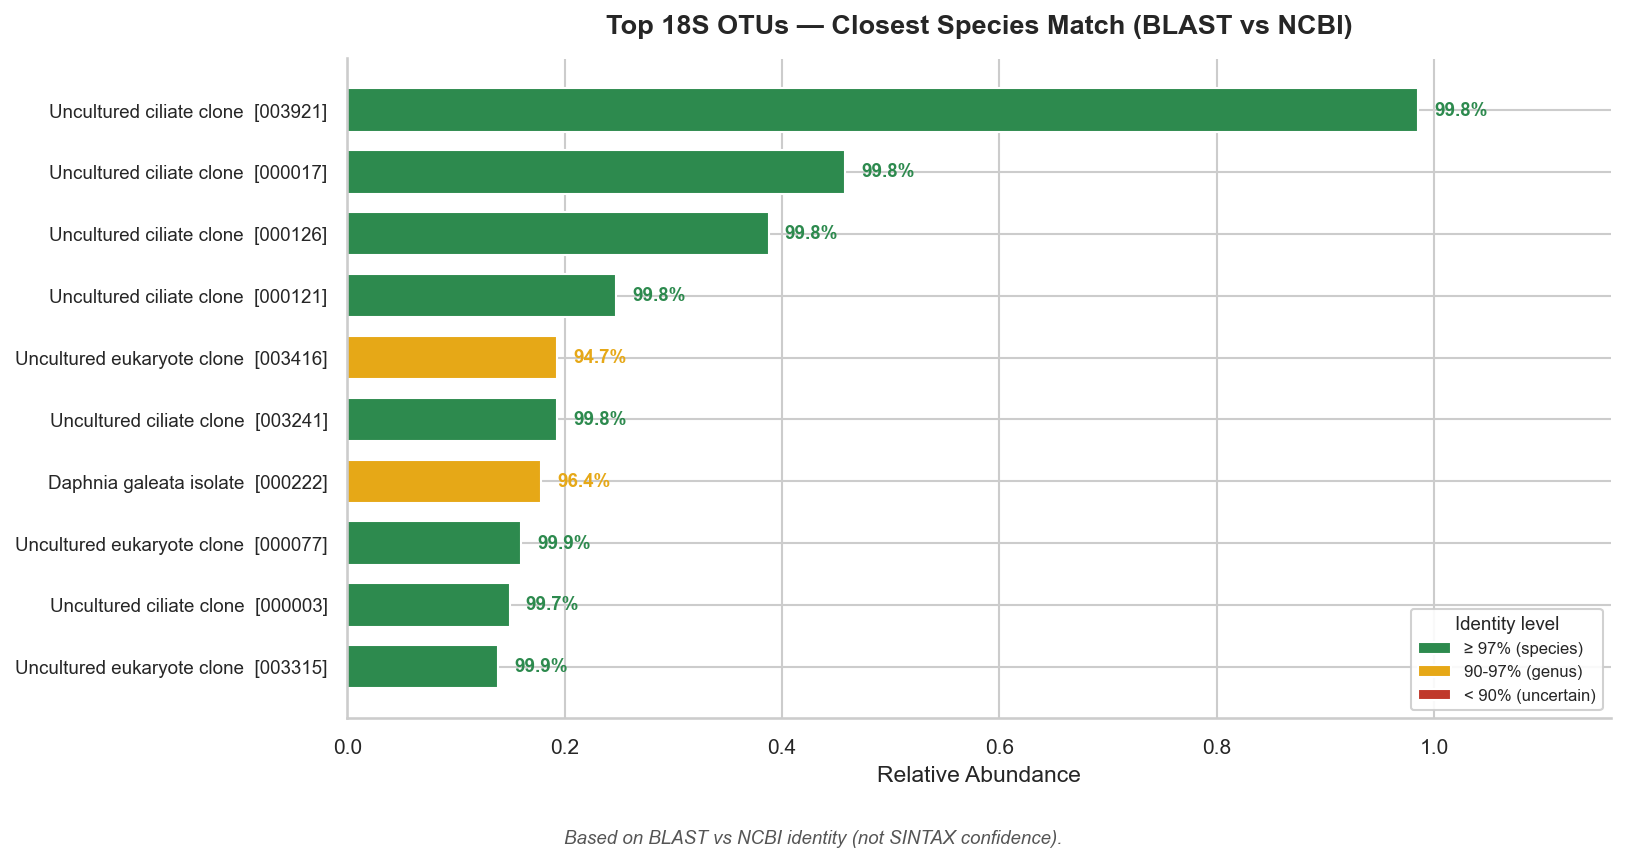

In [35]:
def parse_blast_file(filepath):
    """Parses the custom text output from script 6_blast_top_otus.py"""
    data = []
    try:
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_reading = False
        for line in lines:
            if line.startswith('---'):
                start_reading = True
                continue
            if not start_reading or not line.strip(): continue
            parts = line.split('|')
            if len(parts) >= 4:
                otu_id = parts[0].strip()
                species = parts[2].strip()
                identity_str = parts[3].strip().replace('%', '')
                try:
                    reads = float(parts[1].strip())
                    identity = float(identity_str) if identity_str and identity_str != '-' else None
                    data.append({'OTU': otu_id, 'Species': species, 'Abundance': reads, 'Identity': identity})
                except: continue
    except FileNotFoundError:
        print("BLAST file not found.")
        return pd.DataFrame()
    return pd.DataFrame(data)

df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_18S.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top 18S OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    add_conf_note(kind='blast')
    plt.show()
else:
    print("No valid BLAST data found to plot.")

# Part B: COI Marker Biodiversity Analysis (Porter CO1)
*Objective: To characterize the metazoan community structure using the COI marker with the Porter CO1 Classifier (6.8 GB).*

**Technical Context:** The Porter CO1 Classifier is based on GenBank + BOLD combined, providing broad metazoan coverage:
* **Balanced performance:** 10.3% phylum → 5.0% species at conf ≥ 0.8 (Water dataset).
* **Pre-formatted for SINTAX:** Direct drop-in for the VSEARCH pipeline.
* **NCBI-style taxonomy:** Standard rank hierarchy (Domain, Kingdom, Phylum, Class, Order, Family, Genus, Species).
* **Ciliate limitation:** Like all COI databases, Porter cannot overcome the ciliate-dominance issue — that requires wet-lab blocking primers.

## B.1.a Broad Taxonomic Structure (COI)
This stacked bar chart visualizes the relative abundance of Phyla across all samples using the COI marker.
* **Expected Result:** Ciliate-dominated signal, with some arthropod and metazoan detections.
* **Comparison:** Check whether Porter classifies the same OTUs that MIDORI2 and eKOI assigned differently.

[COI] Phylum: Unassigned = 96.9% of reads


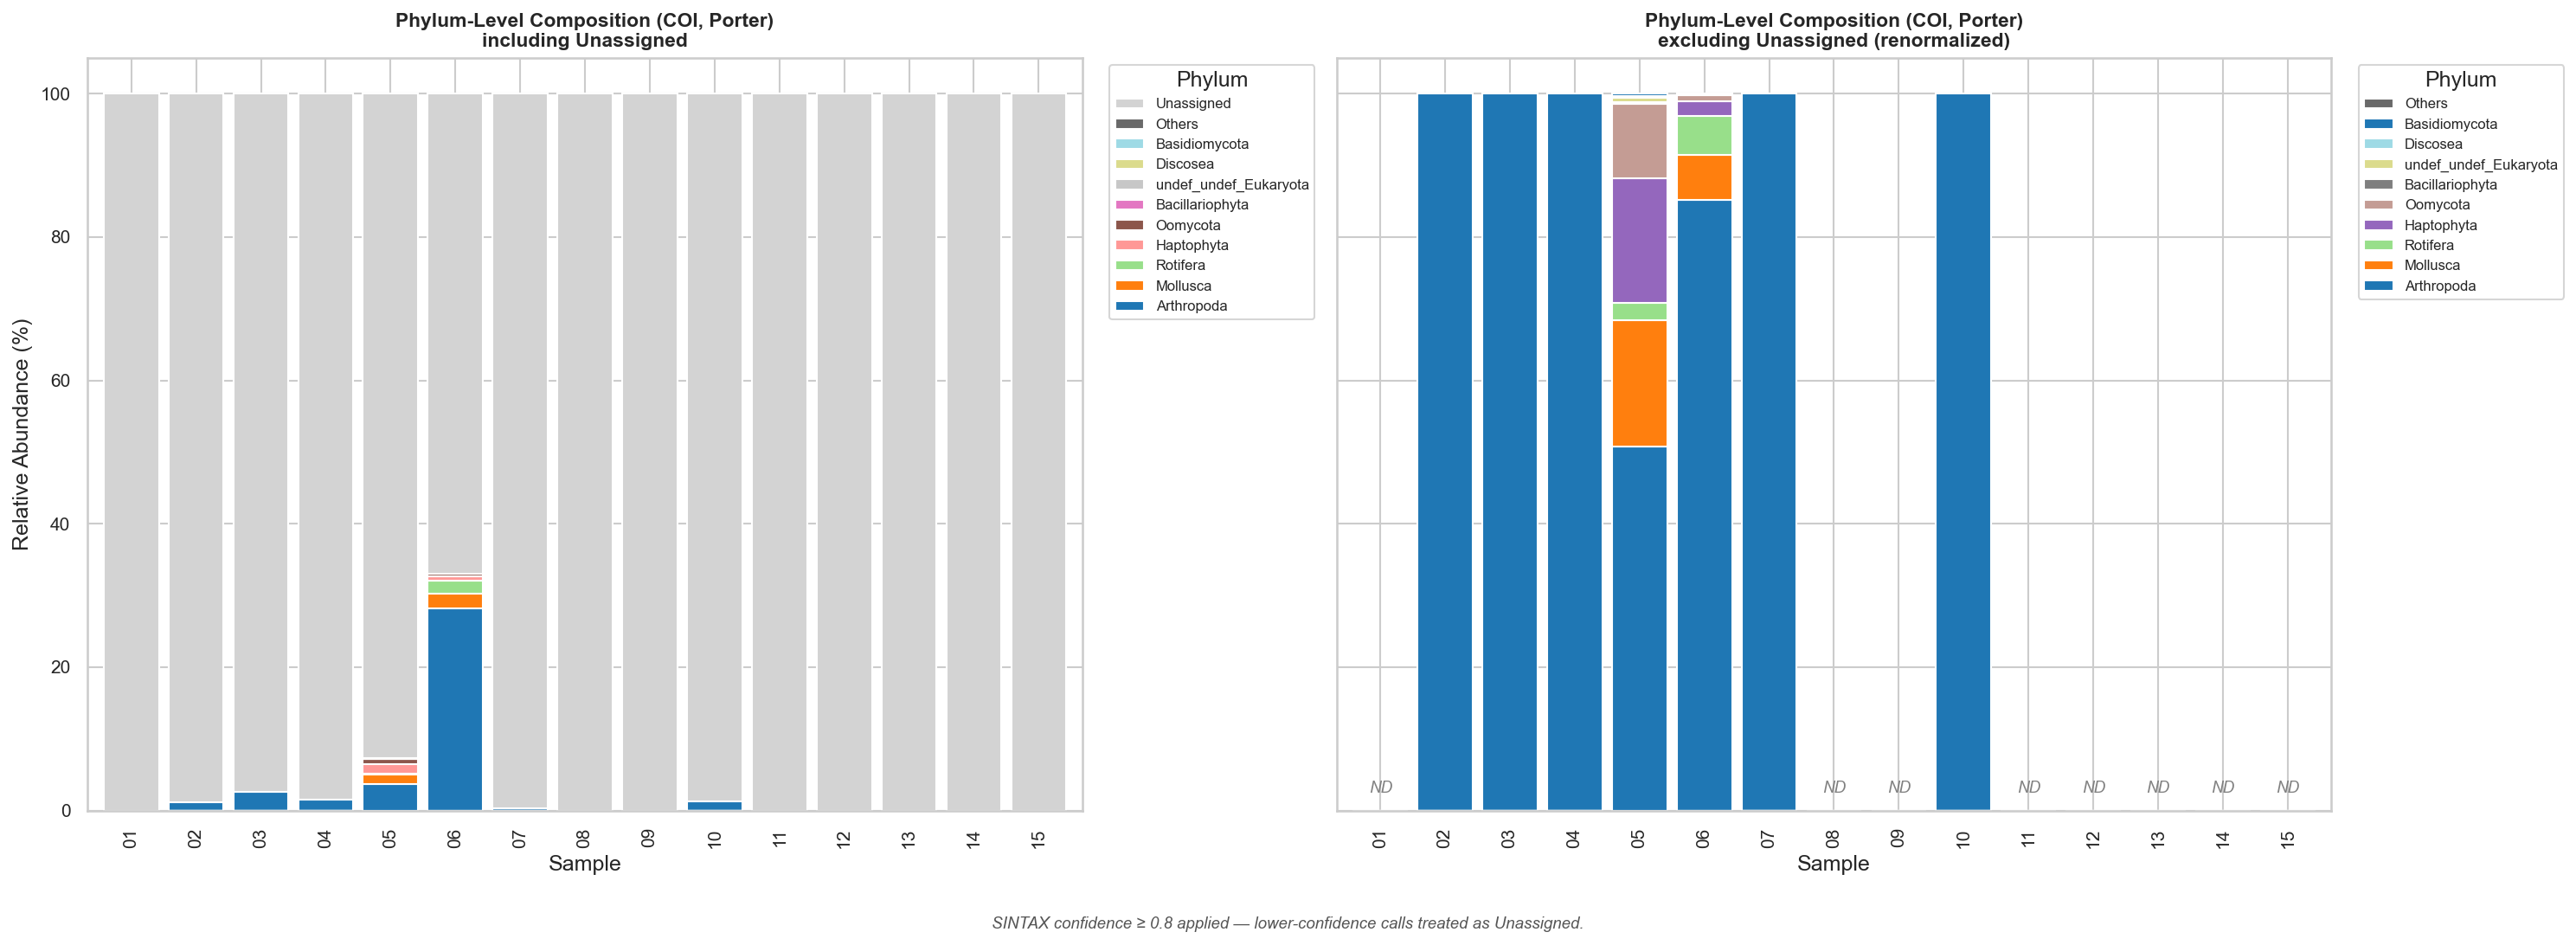

In [36]:
df_coi = df_coi_raw.copy() if "df_coi" not in dir() else df_coi
rank_prefixes = re.compile(r'^(kingdom|phylum|class|order|family|genus|species)_', re.IGNORECASE)
tax_levels_coi = [f'{prefix_coi}_{r}' for r in ['Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']]
for col in tax_levels_coi:
    if col in df_coi.columns:
        df_coi[col] = df_coi[col].apply(
            lambda x: rank_prefixes.sub('', str(x)) if pd.notna(x) else x
        )
        df_coi[col] = df_coi[col].apply(
            lambda x: '_'.join(str(x).rsplit('_', 1)[:-1])
            if pd.notna(x) and '_' in str(x) and str(x).rsplit('_', 1)[-1].isdigit()
            else x
        )


sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Phylum', prefix_coi, 'COI', sample_cols_coi, top_n=10)


## B.1.b Class-Level Breakdown (COI)
**Objective:** To see which specific biological Classes dominate for the COI marker with Porter.

**Visual Analysis:**
1. **Insecta:** The dominant arthropod Class in most samples.
2. **Sordariomycetes (Fungi):** Fungal classes may appear due to off-target amplification.
3. **Comparison with other DBs:** Does Porter classify the same taxa as MIDORI2/eKOI, or do the class-level profiles differ?

[COI] Class: Unassigned = 97.5% of reads


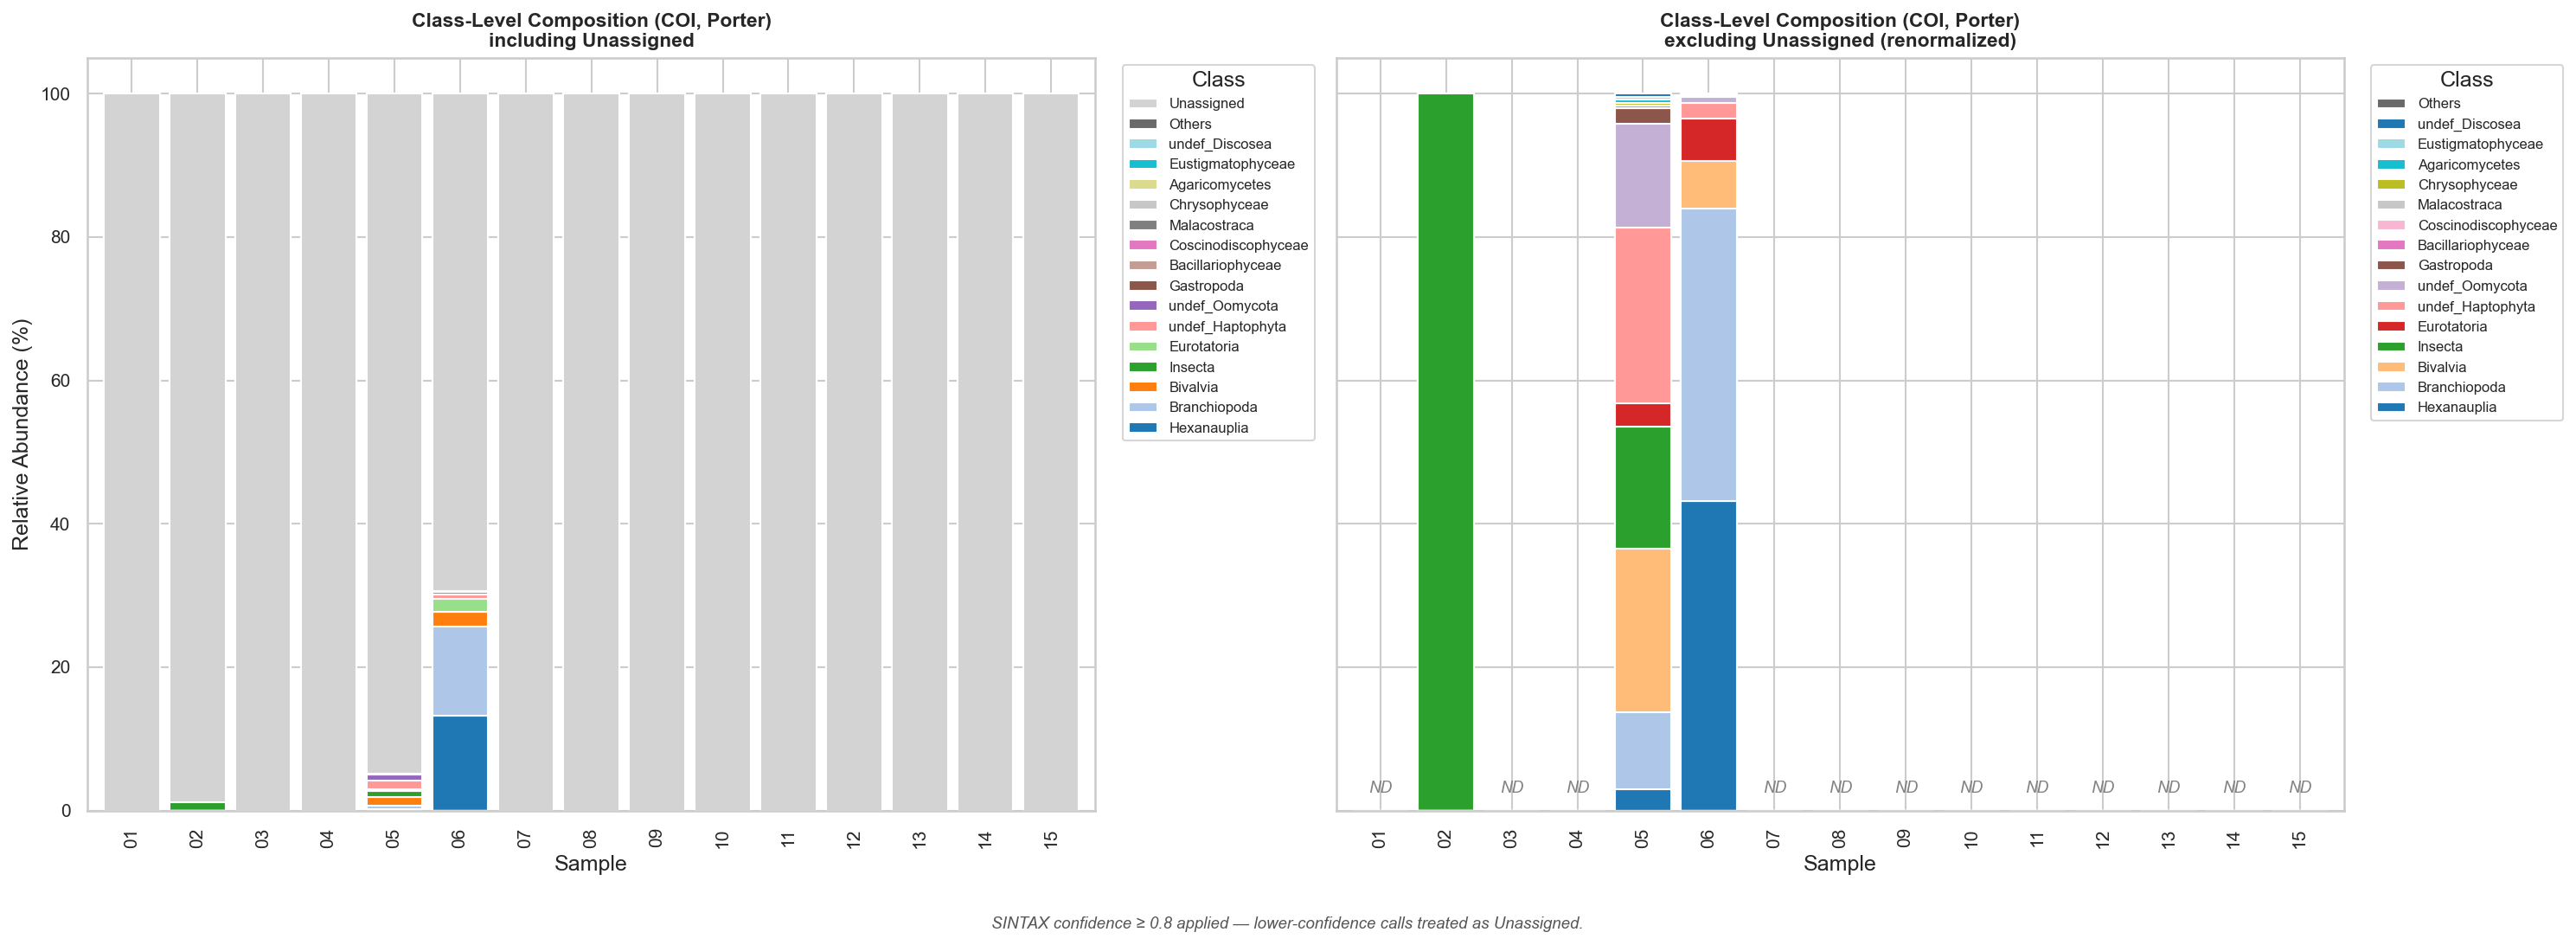

In [37]:
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Class', prefix_coi, 'COI', sample_cols_coi, top_n=15)


## B.2 Order-Level Breakdown (COI)
Order-level community composition for COI marker.

[COI] Order: Unassigned = 97.6% of reads


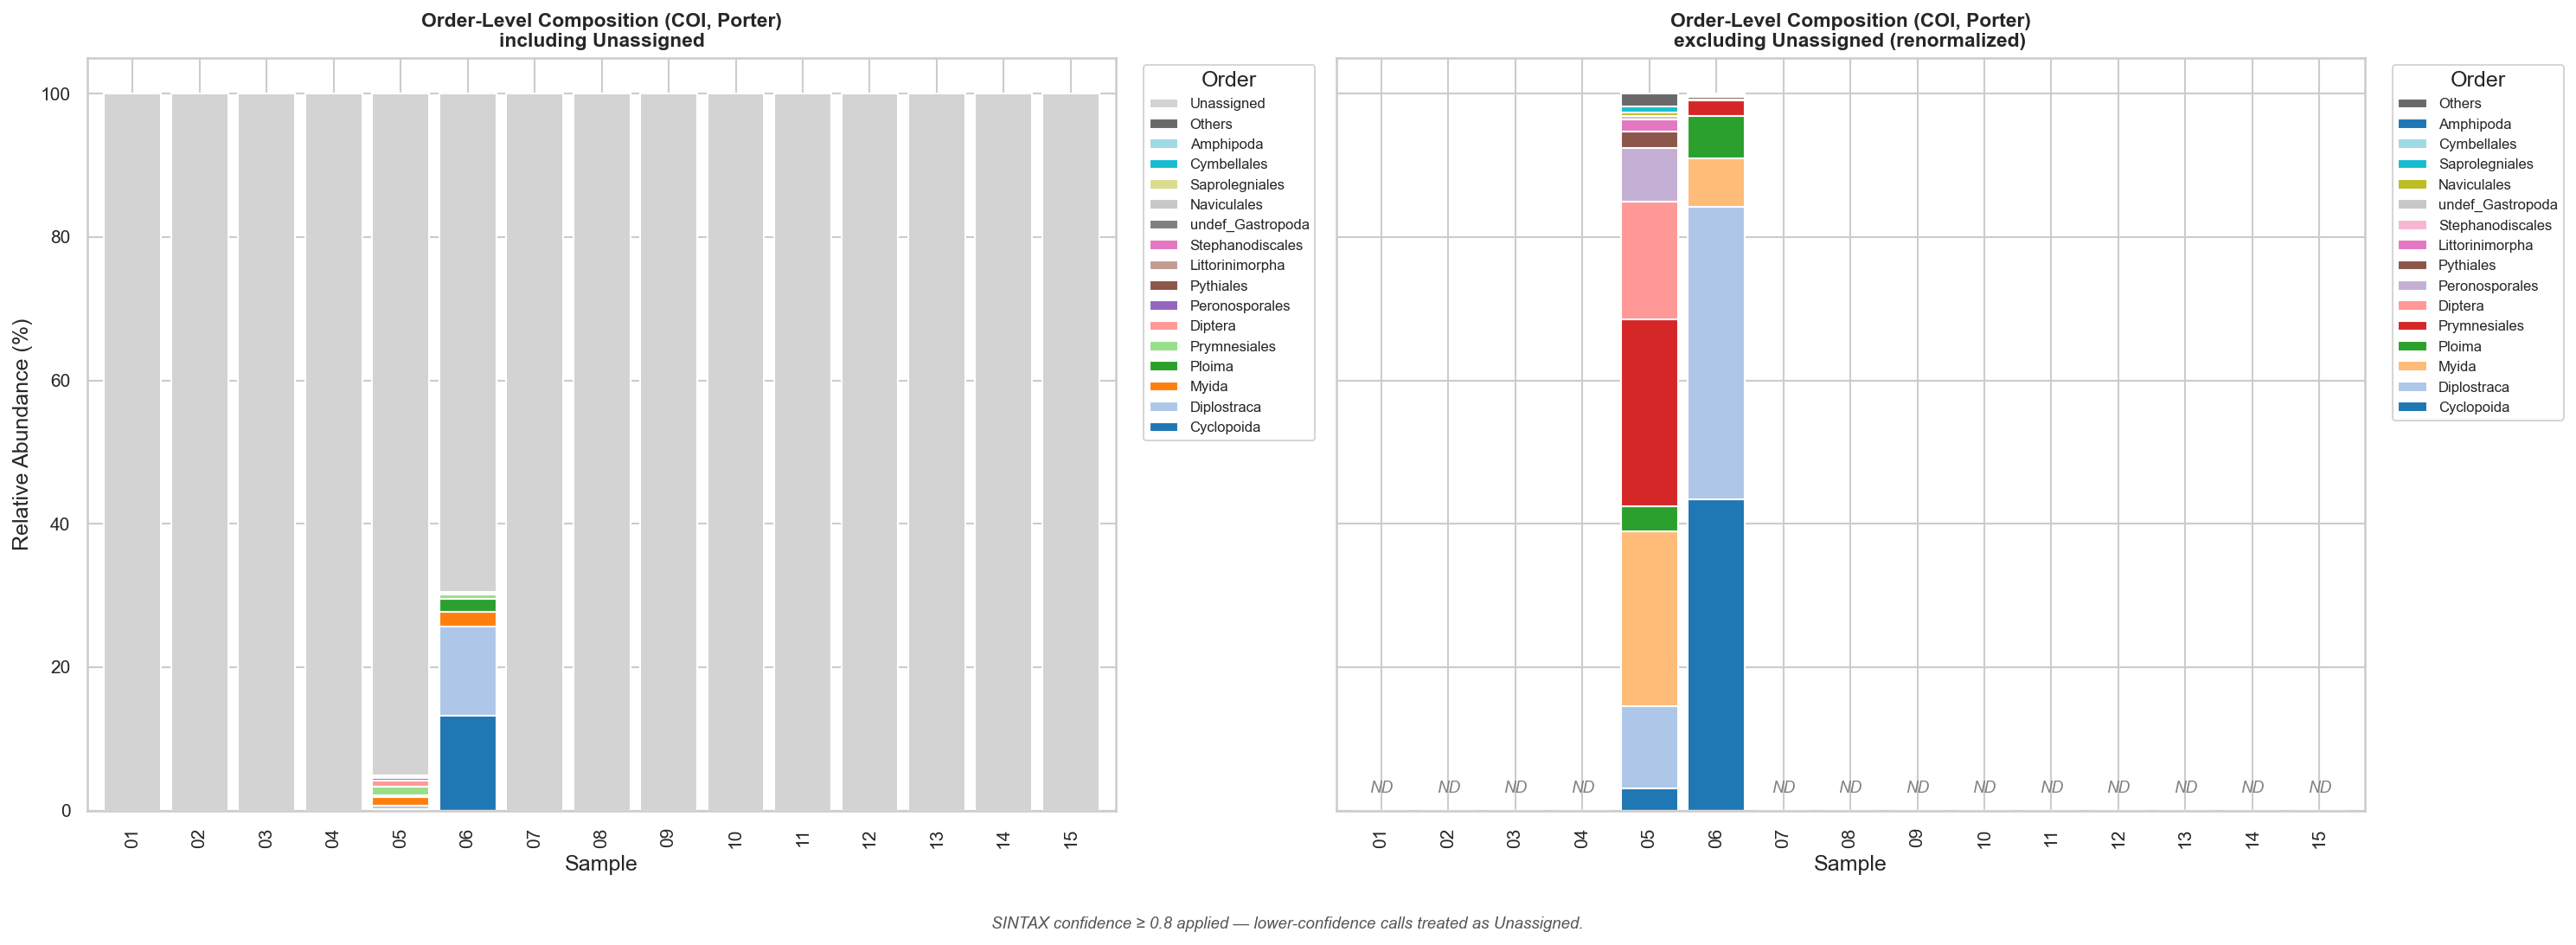

In [38]:
sample_cols_coi = [c for c in df_coi.columns if c.startswith('Sample_') and 'unclassified' not in c]
stacked_bar_compare(df_coi, 'Order', prefix_coi, 'COI', sample_cols_coi, top_n=15)


## B.3 Genus-Level Top 20 (COI)
Top genera detected by the COI marker with confidence annotations.

C:\Users\ilias\AppData\Local\Temp\ipykernel_26400\525363299.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)


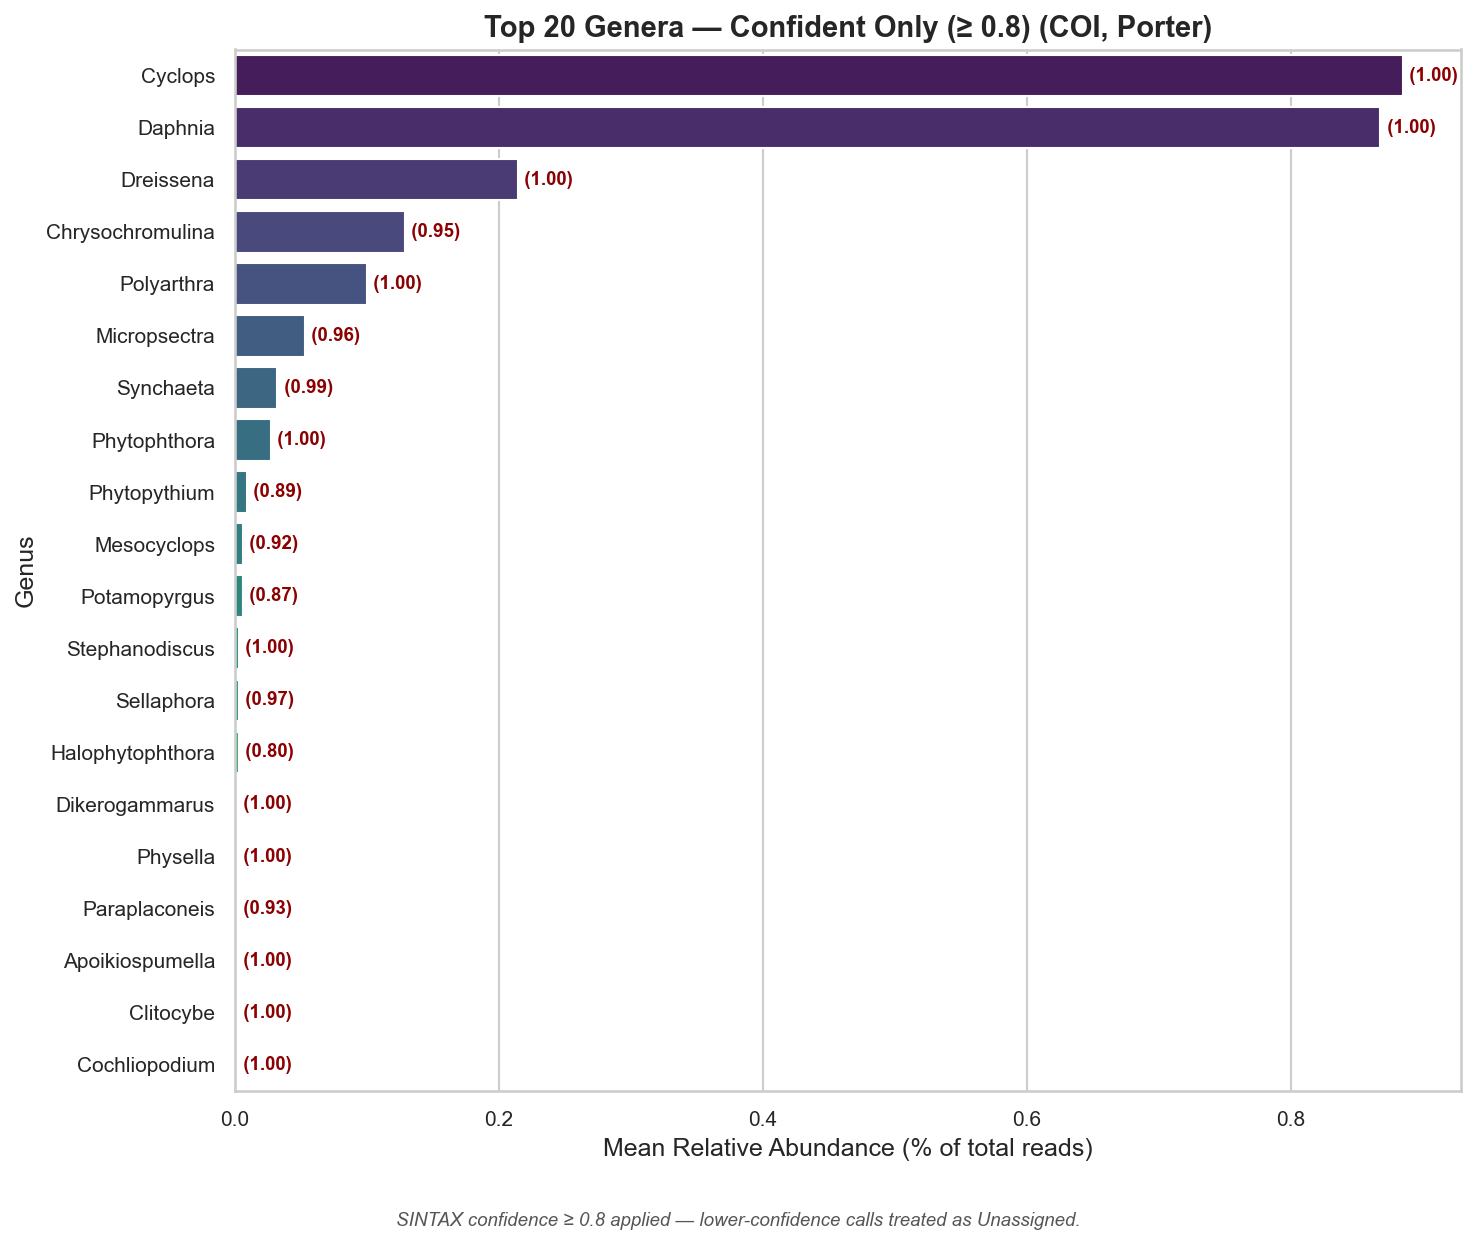

In [39]:
# Top 20 Genera — Confident assignments only (confidence >= 0.8)
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_coi[genus_col] = df_coi[genus_col].fillna('Unassigned')

# Filter to only OTUs with genus confidence >= 0.8
if conf_col in df_coi.columns:
    mask_conf = pd.to_numeric(df_coi[conf_col], errors='coerce') >= 0.8
    df_conf = df_coi[mask_conf].copy()
else:
    df_conf = df_coi[df_coi[genus_col] != 'Unassigned'].copy()

genus_agg = df_conf.groupby(genus_col)[sample_cols_coi].sum()
genus_agg = genus_agg.drop('Unassigned', errors='ignore')
genus_agg['Total'] = genus_agg.div(df_coi[sample_cols_coi].sum(axis=0), axis=1).mean(axis=1) * 100
genus_agg = genus_agg.sort_values('Total', ascending=False)
top20 = genus_agg.head(20)

# Mean confidence per genus
genus_conf = {}
if conf_col in df_conf.columns:
    for genus in top20.index:
        mask = df_conf[genus_col] == genus
        vals = pd.to_numeric(df_conf.loc[mask, conf_col], errors='coerce').dropna()
        genus_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=top20['Total'], y=top20.index, palette='viridis', ax=ax)
ax.set_title(f'Top 20 Genera — Confident Only (\u2265 0.8) (COI, {prefix_coi})', fontweight='bold')
ax.set_xlabel('Mean Relative Abundance (% of total reads)')
ax.set_ylabel('Genus')

if genus_conf:
    for j, genus in enumerate(top20.index):
        conf = genus_conf.get(genus)
        if conf is not None:
            ax.text(top20.loc[genus, 'Total'] + 0.001, j,
                    f' ({conf:.2f})', va='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
add_conf_note(kind='filtered')
plt.show()

### Top 20 Genera by Abundance — All Confidences (COI)
Same marker but showing ALL genus assignments regardless of confidence, ranked by abundance. Bars are color-coded by mean confidence level.

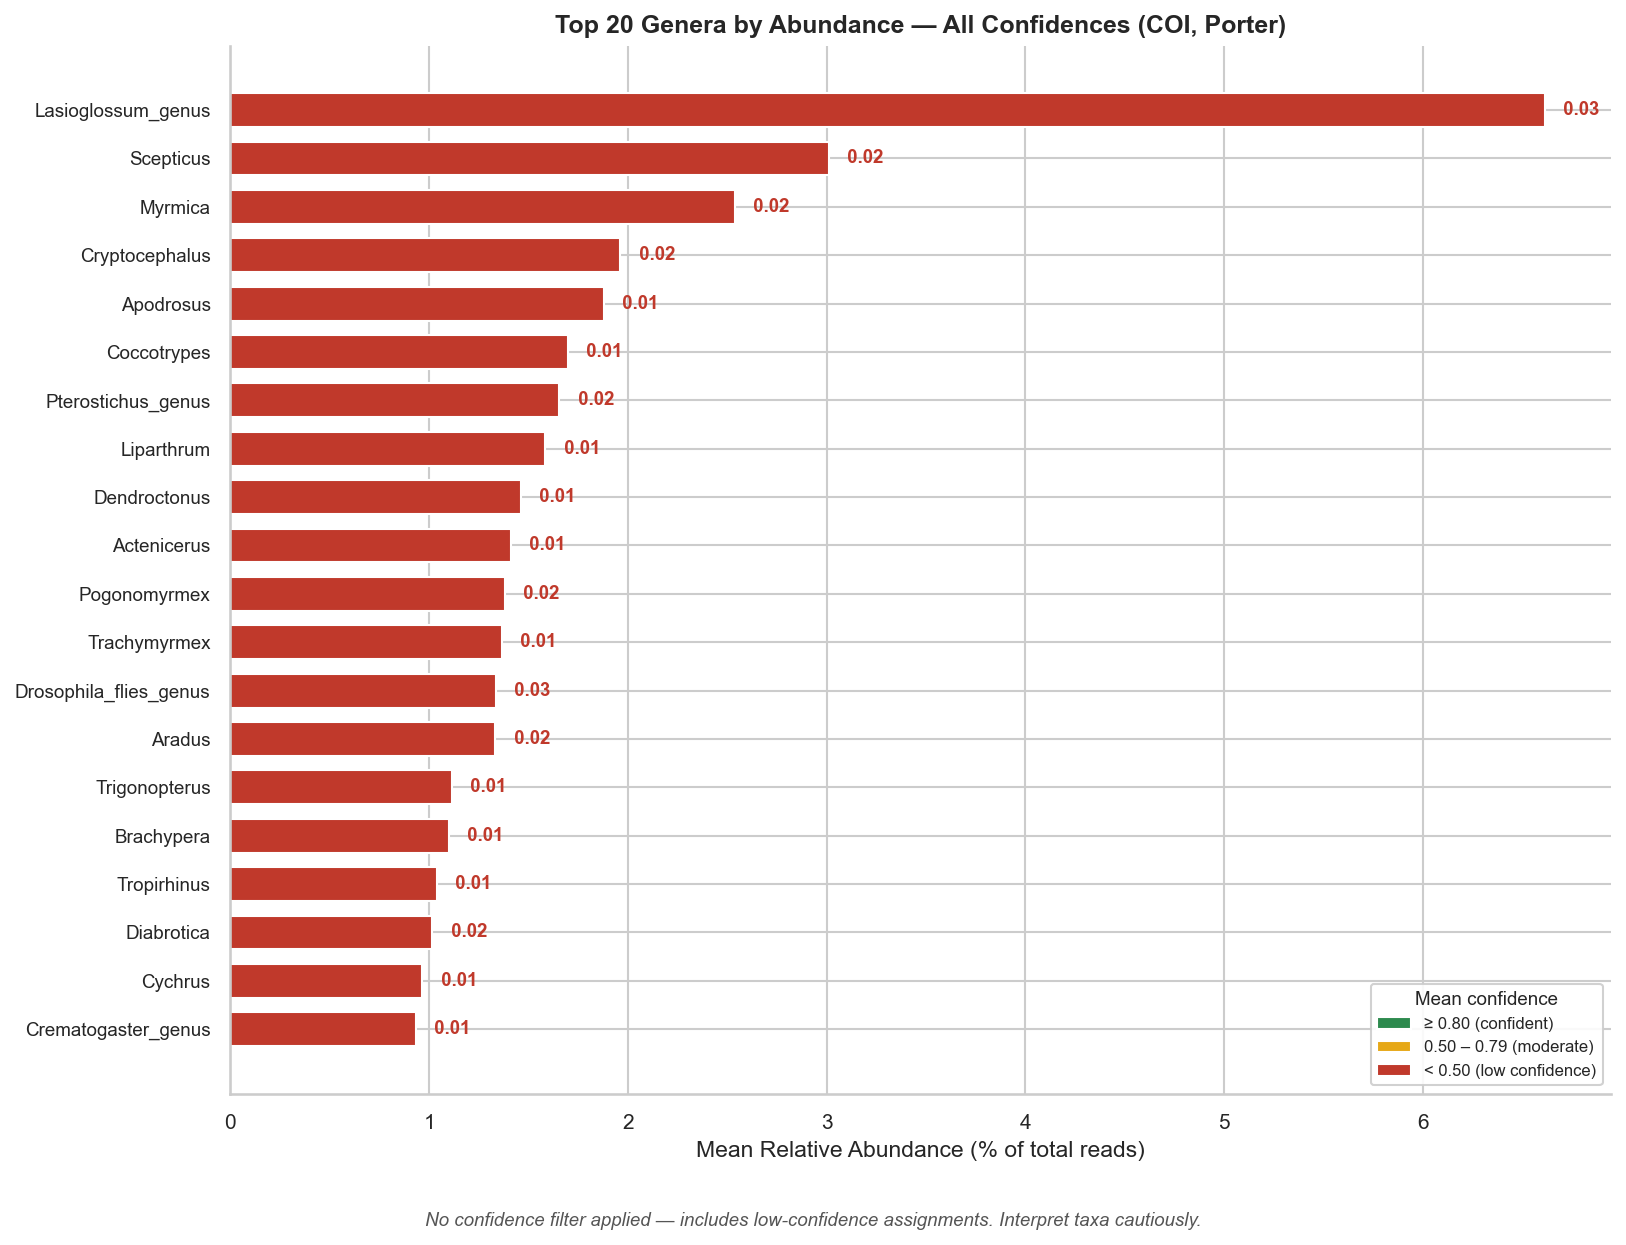

In [40]:
# Top 20 Genera by ABUNDANCE — All confidence levels
genus_col = f'{prefix_coi}_Genus'
conf_col = f'{prefix_coi}_Genus_Conf'
df_tmp = df_coi.copy()
df_tmp[genus_col] = df_tmp[genus_col].fillna('Unassigned')

genus_abund = df_tmp.groupby(genus_col)[sample_cols_coi].sum()
genus_abund = genus_abund.drop('Unassigned', errors='ignore')
genus_abund['Total'] = genus_abund.div(df_coi[sample_cols_coi].sum(axis=0), axis=1).mean(axis=1) * 100
genus_abund = genus_abund.sort_values('Total', ascending=False)
top20 = genus_abund.head(20)

# Mean confidence per genus
raw_conf = {}
if conf_col in df_tmp.columns:
    for genus in top20.index:
        mask = df_tmp[genus_col] == genus
        vals = pd.to_numeric(df_tmp.loc[mask, conf_col], errors='coerce').dropna()
        raw_conf[genus] = vals.mean() if len(vals) > 0 else None

fig, ax = plt.subplots(figsize=(11, 8))
colors = []
for genus in top20.index:
    c = raw_conf.get(genus)
    if c is None:
        colors.append('#999999')
    elif c >= 0.8:
        colors.append('#2d8a4e')
    elif c >= 0.5:
        colors.append('#e6a817')
    else:
        colors.append('#c0392b')

bars = ax.barh(range(len(top20)), top20['Total'].values[::-1], color=colors[::-1], height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index[::-1], fontsize=9)
ax.set_xlabel('Mean Relative Abundance (% of total reads)', fontsize=11)
ax.set_title(f'Top 20 Genera by Abundance — All Confidences (COI, {prefix_coi})',
             fontweight='bold', fontsize=12)

xmax = top20['Total'].max()
for j, genus in enumerate(top20.index[::-1]):
    c = raw_conf.get(genus)
    if c is not None:
        color = '#2d8a4e' if c >= 0.8 else '#e6a817' if c >= 0.5 else '#c0392b'
        ax.text(top20.loc[genus, 'Total'] + xmax * 0.01, j,
                f' {c:.2f}', va='center', fontsize=9, fontweight='bold', color=color)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2d8a4e', label='\u2265 0.80 (confident)'),
    Patch(facecolor='#e6a817', label='0.50 \u2013 0.79 (moderate)'),
    Patch(facecolor='#c0392b', label='< 0.50 (low confidence)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
          title='Mean confidence', title_fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
add_conf_note(kind='unfiltered')
plt.show()

## B.3b Top 20 Eukaryotic Genera (COI, Porter)
Filtered to **Eukaryota domain only** with **confidence >= 0.8**. Porter may include some bacterial assignments — this filter removes them.

Eukaryota filter: 4157/4456 OTUs (93.3%)


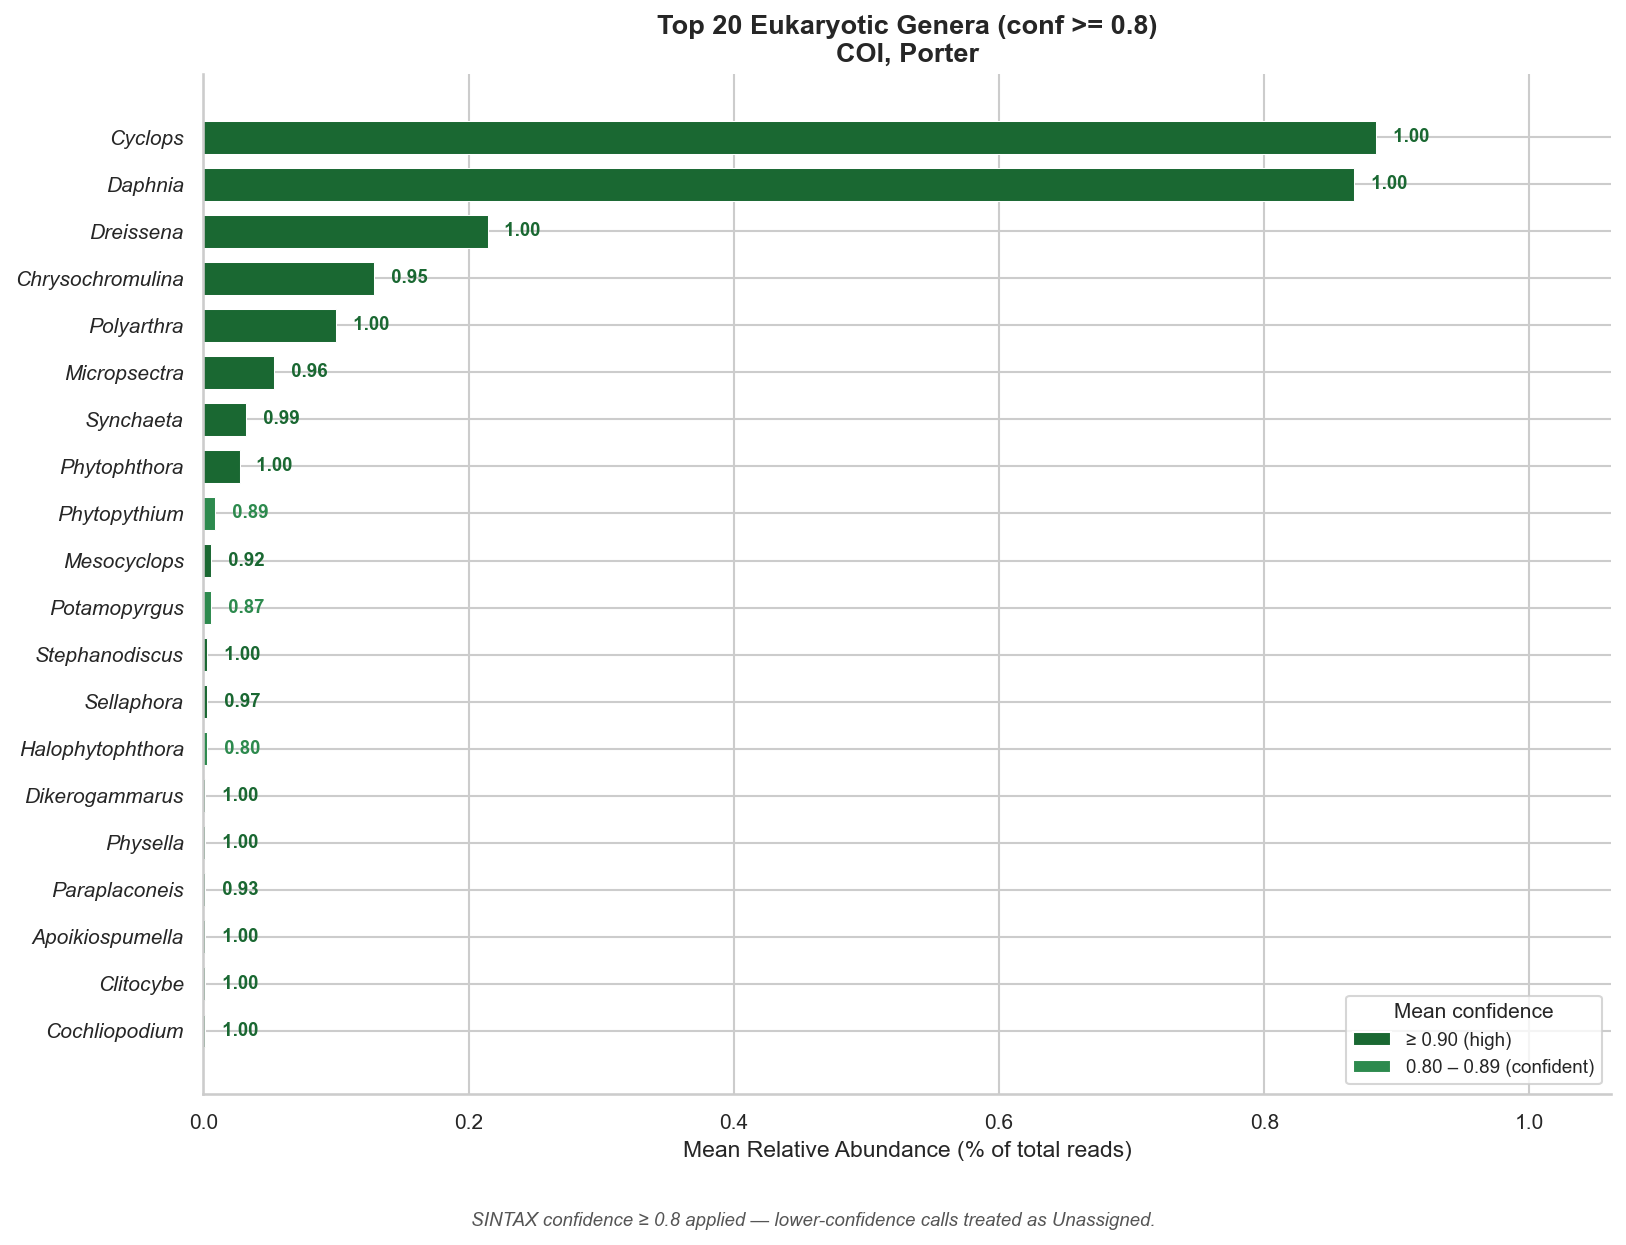


Top 5 Eukaryotic genera (COI, Porter):
  Cyclops: 0.88 % mean abundance (conf 1.00)
  Daphnia: 0.87 % mean abundance (conf 1.00)
  Dreissena: 0.21 % mean abundance (conf 1.00)
  Chrysochromulina: 0.13 % mean abundance (conf 0.95)
  Polyarthra: 0.10 % mean abundance (conf 1.00)


In [41]:
# Top 20 Genera — Eukaryota only, confidence >= 0.8
_df = df_coi.copy()
_prefix = prefix_coi
_genus_col = f'{_prefix}_Genus'
_conf_col = f'{_prefix}_Genus_Conf'
_domain_col = f'{_prefix}_Domain'

# Filter: Eukaryota domain only
if _domain_col in _df.columns:
    _euk_mask = _df[_domain_col].astype(str).str.contains('Eukaryota', case=False, na=False)
    _df = _df[_euk_mask].copy()
    _n_total = len(df_coi)
    _n_euk = len(_df)
    print(f"Eukaryota filter: {_n_euk}/{_n_total} OTUs ({100*_n_euk/_n_total:.1f}%)")
else:
    print(f"No Domain column found ({_domain_col}), using all OTUs")

# Filter: confidence >= 0.8
_df[_genus_col] = _df[_genus_col].fillna('Unassigned')
if _conf_col in _df.columns:
    _conf_mask = pd.to_numeric(_df[_conf_col], errors='coerce') >= CONF_THRESHOLD
    _df = _df[_conf_mask].copy()

# Aggregate by genus
_genus_agg = _df.groupby(_genus_col)[sample_cols_coi].sum()
_genus_agg = _genus_agg.drop('Unassigned', errors='ignore')
_genus_agg['Total'] = _genus_agg.div(df_coi[sample_cols_coi].sum(axis=0), axis=1).mean(axis=1) * 100
_genus_agg = _genus_agg.sort_values('Total', ascending=False)
_top20 = _genus_agg.head(20)

if len(_top20) == 0:
    print("No Eukaryota genera found with confidence >= 0.8")
else:
    # Mean confidence per genus
    _genus_conf = {}
    if _conf_col in _df.columns:
        for _g in _top20.index:
            _vals = pd.to_numeric(_df.loc[_df[_genus_col] == _g, _conf_col], errors='coerce').dropna()
            _genus_conf[_g] = _vals.mean() if len(_vals) > 0 else None

    fig, ax = plt.subplots(figsize=(11, 8))
    colors = []
    for _g in _top20.index:
        c = _genus_conf.get(_g)
        if c is None:
            colors.append('#999999')
        elif c >= 0.9:
            colors.append('#1a6832')
        elif c >= 0.8:
            colors.append('#2d8a4e')
        else:
            colors.append('#e6a817')

    bars = ax.barh(range(len(_top20)), _top20['Total'].values[::-1],
                   color=colors[::-1], height=0.7, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(_top20)))
    ax.set_yticklabels(_top20.index[::-1], fontsize=10, style='italic')
    ax.set_xlabel('Mean Relative Abundance (% of total reads)', fontsize=11)
    ax.set_title(f'Top 20 Eukaryotic Genera (conf >= {CONF_THRESHOLD})\nCOI, Porter',
                 fontweight='bold', fontsize=13)

    _xmax = _top20['Total'].max()
    for j, _g in enumerate(_top20.index[::-1]):
        c = _genus_conf.get(_g)
        if c is not None:
            ax.text(_top20.loc[_g, 'Total'] + _xmax * 0.01, j,
                    f' {c:.2f}', va='center', fontsize=9, fontweight='bold',
                    color='#1a6832' if c >= 0.9 else '#2d8a4e')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1a6832', label='\u2265 0.90 (high)'),
        Patch(facecolor='#2d8a4e', label='0.80 \u2013 0.89 (confident)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
              title='Mean confidence', title_fontsize=10)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, _xmax * 1.2)
    plt.tight_layout()
    add_conf_note(kind='filtered')
    plt.show()

    print(f"\nTop 5 Eukaryotic genera (COI, Porter):")
    for _g in _top20.index[:5]:
        c = _genus_conf.get(_g, 0)
        print(f"  {_g}: {_top20.loc[_g, 'Total']:.2f} % mean abundance (conf {c:.2f})")

## B.4 The "Unassigned" Reality Check (COI)
**Comparison with 18S:** The COI marker has a higher "Unassigned" rate than 18S due to:
1. The strict 0.8 confidence threshold applied to SINTAX assignments
2. Ciliate COI sequences are poorly represented even in large databases
3. Porter's balanced approach means it doesn't over-classify uncertain sequences

## B.5 Forensics: Manual BLAST Identification (COI)
BLAST validation provides database-independent species identification.
1.  **Ciliates:** Top BLAST hits are "uncultured ciliate clones" — consistent across all DB choices.
2.  **Daphnia galeata:** Successfully detected at 96.4% identity.
3.  **Cross-DB consistency:** BLAST results are the same regardless of which SINTAX database was used, confirming the biological signal is real.

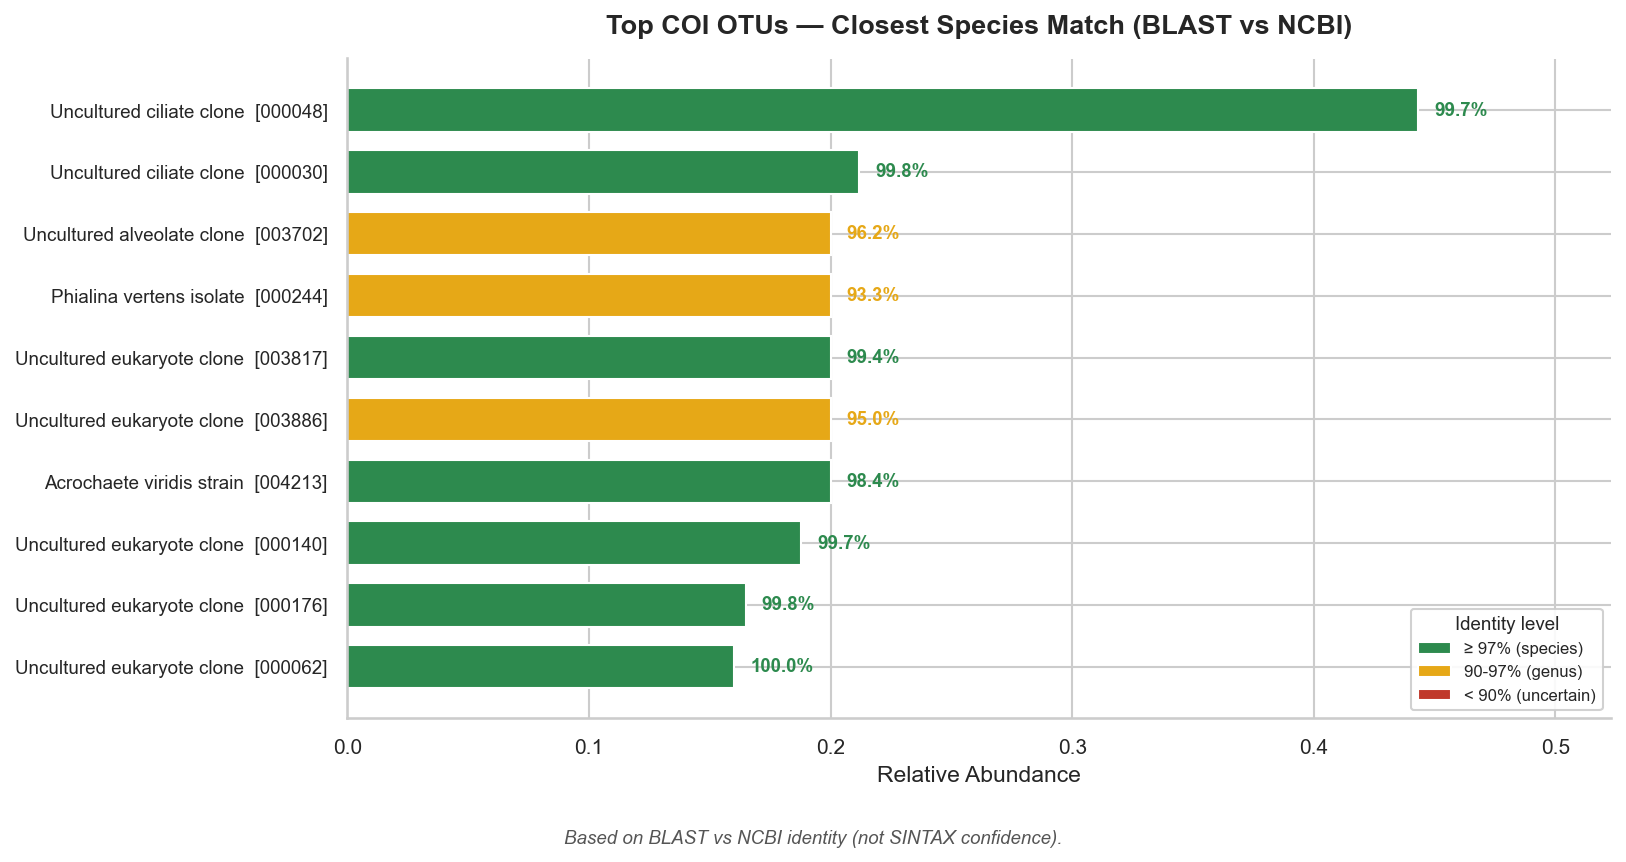

In [42]:
df_blast = parse_blast_file('out/Water_eDNA_18S_COI_14_01_26/blast_results/blast_top10_COI.txt')
if not df_blast.empty:
    df_blast = df_blast.sort_values('Abundance', ascending=True)

    # Build clean labels: Species (short OTU suffix)
    labels = []
    for _, row in df_blast.iterrows():
        otu_short = row['OTU'].split('_')[-1]  # e.g. "005421"
        labels.append(f"{row['Species']}  [{otu_short}]")
    df_blast['Label'] = labels

    # Color by identity tier
    colors = []
    for _, row in df_blast.iterrows():
        if row['Identity'] is None:
            colors.append('#999999')
        elif row['Identity'] >= 97:
            colors.append('#2d8a4e')   # species-level green
        elif row['Identity'] >= 90:
            colors.append('#e6a817')   # genus-level amber
        else:
            colors.append('#c0392b')   # uncertain red

    fig, ax = plt.subplots(figsize=(11, max(3, len(df_blast) * 0.55)))
    bars = ax.barh(range(len(df_blast)), df_blast['Abundance'].values,
                   color=colors, edgecolor='white', height=0.7)

    ax.set_yticks(range(len(df_blast)))
    ax.set_yticklabels(df_blast['Label'].values, fontsize=9)
    ax.set_xlabel('Relative Abundance', fontsize=11)
    ax.set_title('Top COI OTUs — Closest Species Match (BLAST vs NCBI)', fontweight='bold', fontsize=13, pad=12)

    # Annotate identity at bar end
    xmax = df_blast['Abundance'].max()
    for j, (_, row) in enumerate(df_blast.iterrows()):
        if row['Identity'] is not None:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    f"{row['Identity']:.1f}%", va='center',
                    fontsize=9, fontweight='bold', color=colors[j])
        else:
            ax.text(row['Abundance'] + xmax * 0.015, j,
                    "N/A", va='center', fontsize=9, color='#999999')

    # Add legend for identity tiers
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2d8a4e', label='\u2265 97% (species)'),
        Patch(facecolor='#e6a817', label='90-97% (genus)'),
        Patch(facecolor='#c0392b', label='< 90% (uncertain)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=8,
              title='Identity level', title_fontsize=9, framealpha=0.9)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, xmax * 1.18)

    plt.tight_layout()
    add_conf_note(kind='blast')
    plt.show()
else:
    print("No valid BLAST data found to plot.")

---
## Cross-Marker Comparison (18S PR2 vs COI Porter)
Compare the genus-level detections between both markers. This is the recommended database combination, so cross-marker concordance here represents our best biodiversity estimate.

In [43]:
# Compare genus-level detections between 18S and COI
genus_col_18s = f'{prefix_18s}_Genus'
genus_col_coi = f'{prefix_coi}_Genus'

# Only include genera with confidence >= threshold
_g_conf_18s = f'{prefix_18s}_Genus_Conf'
if _g_conf_18s in df_18s.columns:
    _mask_18s = pd.to_numeric(df_18s[_g_conf_18s], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_18s_g = df_18s[_mask_18s]
else:
    _df_18s_g = df_18s
genera_18s = set(_df_18s_g[genus_col_18s].dropna().unique()) - {'Unassigned', ''}
_g_conf_coi = f'{prefix_coi}_Genus_Conf'
if _g_conf_coi in df_coi.columns:
    _mask_coi = pd.to_numeric(df_coi[_g_conf_coi], errors='coerce').fillna(0) >= CONF_THRESHOLD
    _df_coi_g = df_coi[_mask_coi]
else:
    _df_coi_g = df_coi
genera_coi = set(_df_coi_g[genus_col_coi].dropna().unique()) - {'Unassigned', ''}

shared = genera_18s & genera_coi
only_18s = genera_18s - genera_coi
only_coi = genera_coi - genera_18s

print(f"Genera detected by 18S ({prefix_18s}): {len(genera_18s)}")
print(f"Genera detected by COI ({prefix_coi}):  {len(genera_coi)}")
print(f"Shared genera:                  {len(shared)}")
print(f"Only in 18S:                    {len(only_18s)}")
print(f"Only in COI:                    {len(only_coi)}")

if shared:
    print(f"\nShared genera (first 20): {sorted(shared)[:20]}")

Genera detected by 18S (PR2): 198
Genera detected by COI (Porter):  23
Shared genera:                  8
Only in 18S:                    190
Only in COI:                    15

Shared genera (first 20): ['Apoikiospumella', 'Chrysochromulina', 'Cyclops', 'Daphnia', 'Dikerogammarus', 'Mesocyclops', 'Nannochloropsis', 'Phytophthora']


## B.6 Understanding the COI Results
**Key Observation:** The COI marker works correctly but is dominated by ciliate DNA.

1.  **Ciliate Swamping**
    * Ciliates are the most abundant eukaryotes in lake water. Their DNA overwhelms rarer animal signals during PCR.
    * This is a biological reality, not a database or pipeline issue — all 3 COI databases show the same pattern.

2.  **Database Comparison (Water COI, n=6,281 OTUs, conf ≥ 0.8)**
    * **eKOI:** 14.5% phylum → 0.7% species (best at phylum, drops fast)
    * **MIDORI2:** 9.3% phylum → 8.9% species (most consistent deep)
    * **Porter (this notebook):** 10.3% phylum → 5.0% species (balanced)

**Next Steps:**
* **Ciliate-blocking primers** — the highest-priority improvement for animal detection.
* **Cross-marker species reconciliation** — combine 18S and COI detections.

## Part C: Computational Costs
**Summary:**
* **Total Time:** ~42 minutes on a 12-core laptop.
* **Bottleneck:** Clustering (Step 3) took ~54% of the time (N×N comparison).
* **Preprocessing** runs in parallel and is fast. BLAST is slow due to NCBI rate limits.

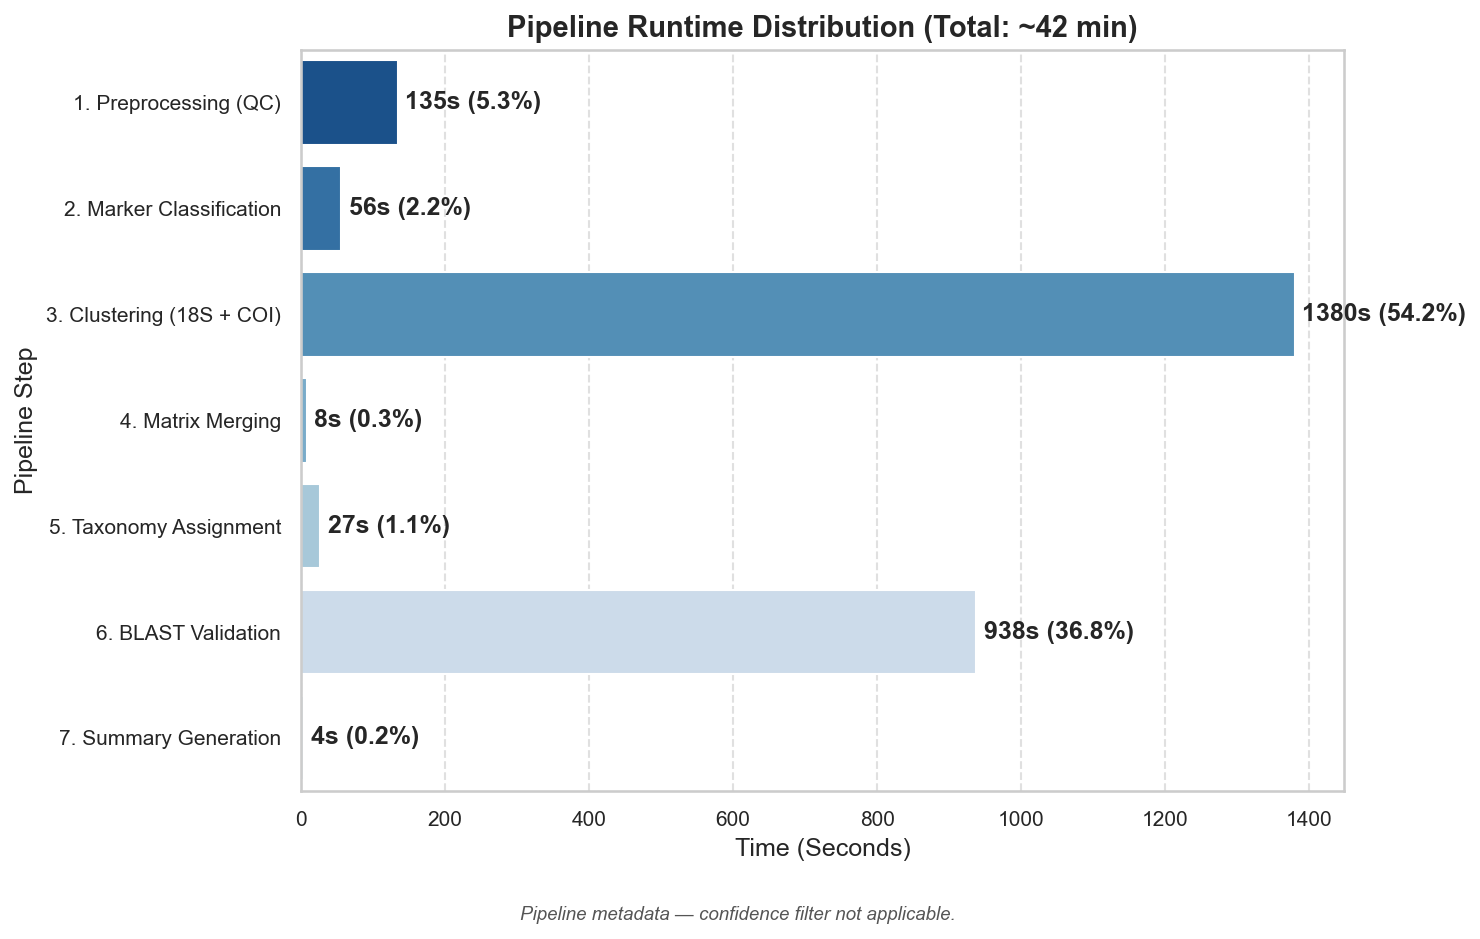

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data extracted manually from log file
timing_data = {
    'Step': [
        '1. Preprocessing (QC)', 
        '2. Marker Classification', 
        '3. Clustering (18S + COI)', 
        '4. Matrix Merging', 
        '5. Taxonomy Assignment', 
        '6. BLAST Validation', 
        '7. Summary Generation'
    ],
    'Time_Seconds': [
        135,   # Preprocessing
        56,    # Classification
        1380,  # Clustering (The bottleneck!)
        8,     # Merging
        27,    # Taxonomy
        938,   # BLAST (Top 10 only)
        4      # Summary
    ]
}

df_time = pd.DataFrame(timing_data)

# Calculate percentages
total_time = df_time['Time_Seconds'].sum()
df_time['Percentage'] = (df_time['Time_Seconds'] / total_time) * 100

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x='Time_Seconds', y='Step', data=df_time, hue='Step', palette='Blues_r', ax=ax, legend=False)

# Add annotations
for i, v in enumerate(df_time['Time_Seconds']):
    pct = df_time.loc[i, 'Percentage']
    ax.text(v + 10, i, f"{int(v)}s ({pct:.1f}%)", va='center', fontweight='bold')

ax.set_title('Pipeline Runtime Distribution (Total: ~42 min)', fontweight='bold')
ax.set_xlabel('Time (Seconds)')
ax.set_ylabel('Pipeline Step')
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
add_conf_note(kind='meta')
plt.show()

# Global confidence threshold for taxonomy filtering
CONF_THRESHOLD = 0.8

# Part D: Methodological Defense & Improvements

### 1. Error Correction Strategy
* **Problem:** Nanopore sequencing has a raw error rate of ~5–10%.
* **Solution:** **95% Identity Clustering** — adapted for Nanopore error profiles.
* *Note:* Nanopore reads have no PCR duplicates (unlike Illumina), so dereplication is not applicable.

### 2. Size Selection
* **18S Filter:** Reads > 3000 bp discarded (concatemers/chimeras).
* **COI Filter:** 300–1000 bp range for the target ~658 bp Folmer region.

### 3. Database Performance Summary
This project tested 5 databases:
* **18S:** PR2 outperforms SILVA at every rank — **PR2 is the recommended 18S database**.
* **COI:** MIDORI2 for deep classification, eKOI for fast screening, Porter for balanced analysis.

### 4. Key Biological Findings
* Lake water eDNA is dominated by ciliates (confirmed by BLAST at >99% identity).
* Confirmed aquatic species: *Daphnia galeata*, *Cyclops abyssorum*, *Dreissena rostriformis* (invasive quagga mussel).
* No vertebrates detected — ciliate-blocking primers needed for fish detection.

### 5. Next Steps
* **Ciliate-blocking primers** — highest priority for targeted animal eDNA.
* **Cross-marker species reconciliation** — unified species list from 18S + COI.
* **Lake Léman-specific reference database** — curate local species sequences for better identification accuracy.

## Database Comparison Summary

This project tested **5 reference databases** across 2 markers:

### Results at a Glance
| Marker | Database | Size | Phylum (conf≥0.8) | Species (conf≥0.8) | Recommendation |
|---|---|---|---|---|---|
| 18S | SILVA | ~23 GB | — | — | Good baseline, weaker for protists |
| 18S | **PR2** | ~220K seq | — | — | **Best for protists/plankton** ✓ |
| COI | MIDORI2 | 9.4 GB | 9.3% | 8.9% | Best deep classification |
| COI | eKOI | 66 MB | 14.5% | 0.7% | Fast screening |
| COI | **Porter** | 6.8 GB | 10.3% | 5.0% | **Balanced choice** ✓ |

**Recommended combination: PR2 (18S) + Porter (COI)** — this notebook.

*All COI rates from Water dataset (n=6,281 OTUs). Soil COI rates <1% at conf ≥ 0.8 for all databases.*